# Моделирование числа покупателей

## Цель ноутбука

Построить прогноз числа покупателей магазина на 7 дней вперед и сравнить его с наивными бейзлайнами на выборке из 40 магазинов из ноутбука `01_data_research`, решения по признакам и обработке данных опираются на выводы ноутбука `02_eda`.

## Правила работы

- **Разбиение строго по времени.** Трейн - до 19.06.2015 включительно, отложенный период - 20.06-31.07.2015 (6 недель).
- **Все решения принимаются по валидации внутри трейна** (фолды раздела 1.2). Отложенный период используется один раз - в финальном сравнении моделей.
- **Метрики считаются только по открытым дням**: закрытые по расписанию дни прогнозируются нулем по правилу.

## 0. Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns

from customers_prediction.config import HOLDOUT_END, HORIZON, SEED, TEST_START, TRAIN_END
from customers_prediction.data import load_history, load_stores, period_days, restore_calendar
from customers_prediction.features import (BASE_FEATURES, BASE_NUMERIC, CATEGORICAL, PROMO_LAGS, build_features,
                                           category_levels, FINAL_FEATURES as CONFIGURED_FEATURES)
from customers_prediction.model import (GuestForecaster, make_lgbm, make_ridge, LGBM_PARAMS as CONFIGURED_LGBM_PARAMS,
                                        RIDGE_ALPHA as CONFIGURED_RIDGE_ALPHA,
                                        SEGMENT_MODELS as CONFIGURED_SEGMENT_MODELS)
from customers_prediction.sarimax import SARIMAX_SPECS, forecast_period, sarimax_exog
from customers_prediction.validation import (BASELINES, FOLDS, baseline_folds, block_bootstrap, compare_to_base,
                                             fold_scores, make_baselines, metrics, run_folds, same_weekday_history,
                                             training_rows)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
FOLD_NAMES = [fold.name for fold in FOLDS]

In [2]:
train_subset = load_history()
stores = load_stores()
selected = stores

print(f"Магазинов: {train_subset['Store'].nunique()}")
print(f"Период данных: {train_subset['Date'].min().date()} - {train_subset['Date'].max().date()}")
selected["segment"].value_counts().rename("магазинов").to_frame()

Магазинов: 40
Период данных: 2013-01-01 - 2015-07-31


,магазинов
segment,
mid,24
high_check,11
high_traffic,5


Календарь "магазин x день" и статусы дней восстанавливаются так же, как в разделе 1.1 ноутбука `02_eda`. Функции проекта (восстановление календаря, признаки, метрики, модели) находятся в пакете `src/customers_prediction` и импортируются в ноутбук; те же функции использует прогноз (`predict.py`).

Календарь строится сразу до конца отложенного периода. Статусы дней отложенного периода нужны только для того, чтобы знать, какие дни входят в метрики; признаками они не становятся.

In [3]:
help(restore_calendar)

Help on function restore_calendar in module customers_prediction.data:

restore_calendar(df: pandas.DataFrame, end: pandas.Timestamp, n_long: int = 3) -> pandas.DataFrame
    Восстанавливает полный календарь "магазин x дата" до даты end включительно
    и присваивает каждому дню статус.
    
    Статусы:
    - open - магазин открыт, число покупателей - реальный спрос;
    - closed - регулярное закрытие: серия Open = 0 короче n_long дней (воскресенье, праздник), покупателей 0;
    - absent - точки нет в этот период: серия Open = 0 от n_long дней (ремонт или магазин появился позже);
    - missing_export - строки нет в выгрузке, значение неизвестно;
    - anomaly - магазин отмечен открытым, но покупателей 0.
    
    Исходные Customers и Sales не меняются, очищенные значения - в customers_clean и sales_clean.



In [4]:
calendar = (restore_calendar(train_subset, end=HOLDOUT_END)
            .sort_values(["Store", "Date"], ignore_index=True))
calendar["segment"] = calendar["Store"].map(selected["segment"])

assert len(calendar) == calendar["Store"].nunique() * calendar["Date"].nunique(), "календарь неполный"

holdout = calendar[calendar["Date"] >= TEST_START]
print(f"Отложенный период: {holdout['Date'].min().date()} - {holdout['Date'].max().date()}, "
      f"{holdout['Date'].nunique()} дней x {holdout['Store'].nunique()} магазинов")
holdout["day_status"].value_counts().rename("дней").to_frame()

Отложенный период: 2015-06-20 - 2015-07-31, 42 дней x 40 магазинов


,дней
day_status,
open,1470
closed,210
absent,0
missing_export,0
anomaly,0


В отложенном периоде 40 магазинов x 42 дня: 1470 открытых дней и 210 закрытых (воскресенья у 35 магазинов, кроме 5 магазинов `high_traffic`, работающих без выходных). Дней без данных, длинных закрытий и аномалий в отложенном периоде нет, поэтому метрики на нем считаются по всем 1470 открытым дням, а закрытые дни получают 0 по правилу.

## 1. Постановка задачи

### 1.1 Схема прогноза

Прогноз делается раз в неделю на 7 дней вперед. Все признаки для дня t берутся из данных не позже t - 7: для любого дня горизонта это данные, известные на дату прогноза. Поэтому одна модель подходит для всех 7 дней горизонта, а заглянуть в будущее она не может по построению. Лаги того же дня недели (7, 14, 21, 28 дней) при таком правиле доступны всегда (раздел 3.4 ноутбука `02_eda`).

Кроме истории, на вход прогноза подается план на 7 дней вперед: расписание работы, промоакции, праздники и школьные каникулы (раздел 8 ноутбука `02_eda`). Эти значения известны заранее и используются для самого дня t.

Отложенный период и фолды валидации проверяются как последовательность недельных прогнозов: для каждой недели история известна до конца предыдущей недели, включая фактические значения уже прошедших недель периода, - так прогноз работал бы в реальности.

### 1.2 Фолды валидации

Для выбора признаков и гиперпараметров используем 3 фолда по 6 недель с расширяющимся окном: модель для каждого фолда обучается на всех данных до его начала. Фолды выбраны так, чтобы проверить разные условия: зимний - рождественский период, весенний - Пасха и майские праздники, летний - последние 6 недель трейна, ближайшие к отложенному периоду. Для сравнения в таблицу добавлен отложенный период.

In [5]:
# фолды заданы в пакете: src/customers_prediction/validation.py
periods = pd.DataFrame([{"fold": fold.name, "start": fold.start, "end": fold.end} for fold in FOLDS]
                       + [{"fold": "отложенный", "start": TEST_START, "end": HOLDOUT_END}])

is_holiday = calendar["StateHoliday"].astype("string").fillna("0").ne("0")
holiday_dates = np.sort(calendar.loc[is_holiday, "Date"].unique())


def describe_period(p: pd.Series) -> pd.Series:
    days = calendar[calendar["Date"].between(p["start"], p["end"])]
    open_days = days[days["day_status"] == "open"]
    return pd.Series({
        "начало": p["start"].date(),
        "конец": p["end"].date(),
        "обучение на данных до": (p["start"] - pd.Timedelta(days=1)).date(),
        "открытых дней": len(open_days),
        "магазинов с открытыми днями": open_days["Store"].nunique(),
        "праздники": ", ".join(pd.Timestamp(d).strftime("%d.%m") for d in holiday_dates
                               if p["start"] <= d <= p["end"]) or "нет",
    })


periods.set_index("fold").apply(describe_period, axis=1)

,начало,конец,обучение на данных до,открытых дней,магазинов с открытыми днями,праздники
fold,,,,,,
зима,2014-12-06,2015-01-16,2014-12-05,1173,40,"25.12, 26.12, 01.01, 06.01"
весна,2015-03-28,2015-05-08,2015-03-27,1365,40,"03.04, 06.04, 01.05"
лето,2015-05-09,2015-06-19,2015-05-08,1377,40,"14.05, 25.05, 04.06"
отложенный,2015-06-20,2015-07-31,2015-06-19,1470,40,нет


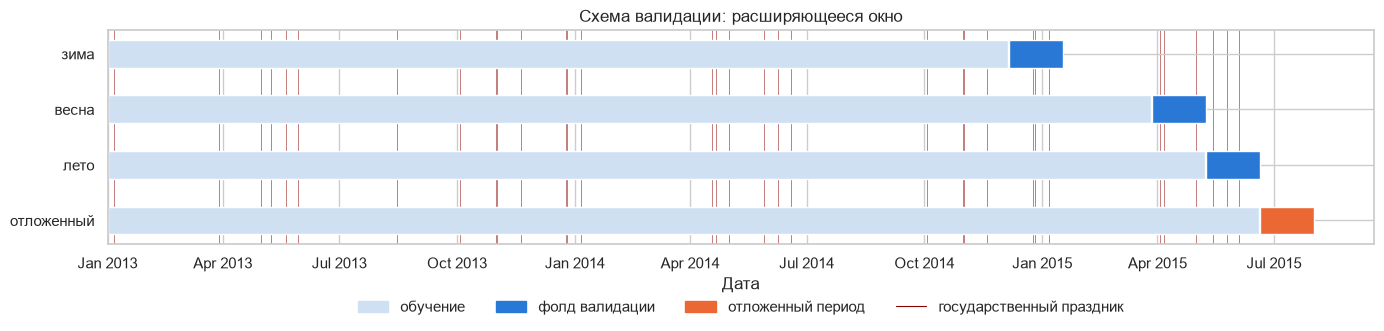

In [6]:
fig, ax = plt.subplots(figsize=(14, 3.6))
data_start = calendar["Date"].min()
for row, p in enumerate(periods.itertuples()):
    train_end = p.start - pd.Timedelta(days=1)
    ax.barh(row, mdates.date2num(train_end) - mdates.date2num(data_start), left=mdates.date2num(data_start),
            color="#cfe0f3", height=0.5)
    ax.barh(row, mdates.date2num(p.end) - mdates.date2num(p.start) + 1, left=mdates.date2num(p.start),
            color="#eb6834" if p.fold == "отложенный" else "#2a78d6", height=0.5)
for day in holiday_dates:
    ax.axvline(day, color="#8B0000", linewidth=0.6, alpha=0.6, zorder=0)
ax.set_yticks(range(len(periods)), periods["fold"])
ax.invert_yaxis()
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set(title="Схема валидации: расширяющееся окно", xlabel="Дата")
ax.legend(handles=[Patch(color="#cfe0f3", label="обучение"), Patch(color="#2a78d6", label="фолд валидации"),
                   Patch(color="#eb6834", label="отложенный период"),
                   plt.Line2D([], [], color="#8B0000", linewidth=0.8, label="государственный праздник")],
          loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

Во всех трех фолдах есть государственные праздники, а в отложенном периоде их нет, предположительно, праздники следующие:
- зимний фолд - Рождество (25-26.12), Новый год (1.01);
- весенний фолд - период Пасхи, День матери;
- летний фолд - точно установить, какие именно это праздники, затруднительно.

Отложенный период проверяет качество на обычных летних днях, а качество в праздники можно оценить только на фолдах. Открытых дней в фолдах от 1173 до 1377, открытые дни есть у всех 40 магазинов; в зимнем фолде у 9 магазинов с пробелом выгрузки открытые дни есть только в январской части. Фолды заметно различаются по сложности, поэтому решения принимаем по среднему по фолдам, но смотрим и на каждый фолд отдельно.

### 1.3 Метрики

Все метрики считаются по открытым дням периода на исходной шкале (число покупателей):
- **MAE** - средняя абсолютная ошибка в покупателях, понятна в бизнес-единицах, но в ней доминируют крупные магазины;
- **MAPE** - средняя относительная ошибка в процентах, каждый магазин и день весят одинаково, поэтому в ней сильнее видны мелкие магазины. Знаменатель не бывает близким к нулю: у открытых дней покупателей всегда больше 0 (аномальные дни с нулем исключены в разделе 0);
- **WAPE** - сумма абсолютных ошибок, деленная на сумму факта: относительная ошибка, в которой магазины весят пропорционально своему потоку, промежуточная между MAE и MAPE.

In [7]:
# метрики - функция пакета (src/customers_prediction/validation.py)
help(metrics)

Help on function metrics in module customers_prediction.validation:

metrics(y_true: pandas.Series, y_pred: pandas.Series) -> pandas.Series
    MAE, MAPE и WAPE по открытым дням (у открытых дней покупателей всегда больше 0).



## 2. Бейзлайны

Все бейзлайны берут значение того же дня недели в прошлом: только открытые дни и не ближе 7 дней назад (раздел 1.1). Если ближайший такой день был закрыт или отсутствует в данных, берется следующая по давности неделя. Так прогноз есть на каждый открытый день, и ни один день не приходится исключать из метрик.

- **`lag_7`** - тот же день неделю назад, обязательный наивный бейзлайн;
- **`lag_14`** - тот же день две недели назад (только четное число недель назад): из-за чередования промоакции это чаще та же фаза промоакции (разделы 3.2 и 3.4 ноутбука `02_eda`);
- **`median_7_28`** - медиана того же дня 1-4 недели назад: сглаживает разовые отклонения, но смешивает недели с промоакцией и без.

In [8]:
# бейзлайны - функции пакета (src/customers_prediction/validation.py)
history = same_weekday_history(calendar)    # тот же день недели 1..52 недели назад, только открытые дни
baselines = make_baselines(calendar)        # lag_7, lag_14, median_7_28

# сколько недель назад пришлось заглянуть: ближайшая доступная неделя
source_week = history.notna().idxmax(axis=1).where(history.notna().any(axis=1))
source_week_14 = history[history.columns[1::2]].notna().idxmax(axis=1)

rows = []
for fold in FOLDS:
    days = period_days(calendar, fold.start, fold.end)
    for name, weeks in [("lag_7", source_week), ("lag_14", source_week_14)]:
        w = weeks.loc[days.index]
        nearest = 1 if name == "lag_7" else 2
        rows.append({"fold": fold.name, "бейзлайн": name,
                     "ближайшая неделя, % дней": (w == nearest).mean() * 100,
                     "дальше, но не старше 4 недель, % дней": ((w > nearest) & (w <= 4)).mean() * 100,
                     "старше 4 недель, % дней": (w > 4).mean() * 100,
                     "магазинов со значениями старше 4 недель": days.loc[w > 4, "Store"].nunique()})
pd.DataFrame(rows).set_index(["fold", "бейзлайн"]).round(1)

ближайшая неделя, % дней  \
fold  бейзлайн                             
зима  lag_7                         90.7   
      lag_14                        84.9   
весна lag_7                         92.3   
      lag_14                        94.9   
лето  lag_7                         93.2   
      lag_14                        90.7   

                дальше, но не старше 4 недель, % дней  \
fold  бейзлайн                                          
зима  lag_7                                       4.7   
      lag_14                                      6.6   
весна lag_7                                       7.7   
      lag_14                                      5.1   
лето  lag_7                                       6.8   
      lag_14                                      9.3   

                старше 4 недель, % дней  \
fold  бейзлайн                            
зима  lag_7                         4.6   
      lag_14                        8.4   
весна lag_7                         0.0   
      lag_14                        0.0   
лето  lag_7                         0.0   
      lag_14                        0.0   

                магазинов со значениями старше 4 недель  
fold  бейзлайн                                           
зима  lag_7                                           9  
      lag_14                                          9  
весна lag_7                                           0  
      lag_14                                          0  
лето  lag_7                                           0  
      lag_14                                          0

В весеннем и летнем фолдах `lag_7` в 92-93% дней берет значение ровно неделю назад, а в остальных случаях - из 2-4 недель назад (ближайший такой день был закрыт, например, в праздник). В зимнем фолде 4.6% прогнозов `lag_7` и 8.4% прогнозов `lag_14` взяты из значений старше 4 недель: это 9 магазинов с пробелом выгрузки, у которых в январе ближайшие данные - июнь 2014 года.

**Для модели:** у этих магазинов в начале 2015 года нет недавней истории, и модель столкнется с той же проблемой, что и бейзлайн (лаги не протягиваются через пробел выгрузки).

In [9]:
rows = []
for fold in FOLDS:
    days = period_days(calendar, fold.start, fold.end)
    for name in BASELINES:
        rows.append({"fold": fold.name, "бейзлайн": name,
                     **metrics(days["customers_clean"], baselines.loc[days.index, name])})
baseline_scores = pd.DataFrame(rows)

summary = baseline_scores.pivot(index="бейзлайн", columns="fold", values=["MAE", "MAPE, %", "WAPE, %"])
summary = summary.reindex(columns=["зима", "весна", "лето"], level=1).reindex(BASELINES)
for metric in ["MAE", "MAPE, %", "WAPE, %"]:
    summary[(metric, "среднее")] = summary[metric].mean(axis=1)
summary.sort_index(axis=1, level=0, sort_remaining=False).round(1)

MAE                       MAPE, %                     WAPE, %  \
fold          зима  весна   лето среднее    зима весна  лето среднее    зима   
бейзлайн                                                                       
lag_7        192.4  159.4  120.1   157.3    23.7  19.1  14.9    19.2    21.3   
lag_14       204.5  117.5   95.4   139.1    25.3  13.9  12.0    17.1    22.7   
median_7_28  170.2  101.1   84.8   118.7    21.3  11.8  10.6    14.6    18.9   

                                 
fold        весна  лето среднее  
бейзлайн                         
lag_7        18.4  14.0    17.9  
lag_14       13.5  11.1    15.8  
median_7_28  11.6   9.9    13.5

Лучший бейзлайн во всех трех фолдах - `median_7_28`: в среднем по фолдам MAE 118.7 покупателя и MAPE 14.6% против 157.3 и 19.2% у обязательного `lag_7`. `lag_14` лучше `lag_7` весной и летом (MAPE 13.9% против 19.1% и 12.0% против 14.9%), но хуже зимой (25.3% против 23.7%): в рождественский период спрос быстро меняется, и значение двухнедельной давности устаревает сильнее.

Сложность фолдов сильно различается: зимой MAPE бейзлайнов 21-25%, летом - 11-15%. Летний фолд ближе всего к отложенному периоду по условиям. WAPE у всех бейзлайнов ниже MAPE: у мелких магазинов относительная ошибка больше, чем у крупных.

**Для модели:** улучшение нужно показывать не только относительно обязательного `lag_7`, но и относительно самого сильного бейзлайна `median_7_28` - это более честная планка.

Проверим вывод раздела 3.2 ноутбука `02_eda`: лаг 7 должен систематически ошибаться из-за чередования наличия/отсутствия промоакций. Если неделю назад фаза промоакции была другой, лаг 7 занижает прогноз в дни с промоакцией и завышает в дни без промоакции. Поэтому сравниваем не только среднюю абсолютную ошибку, но и среднюю ошибку со знаком, выраженную в процентах от фактического значения. Положительное смещение означает, что бейзлайн в среднем завышает прогноз, отрицательное - занижает.

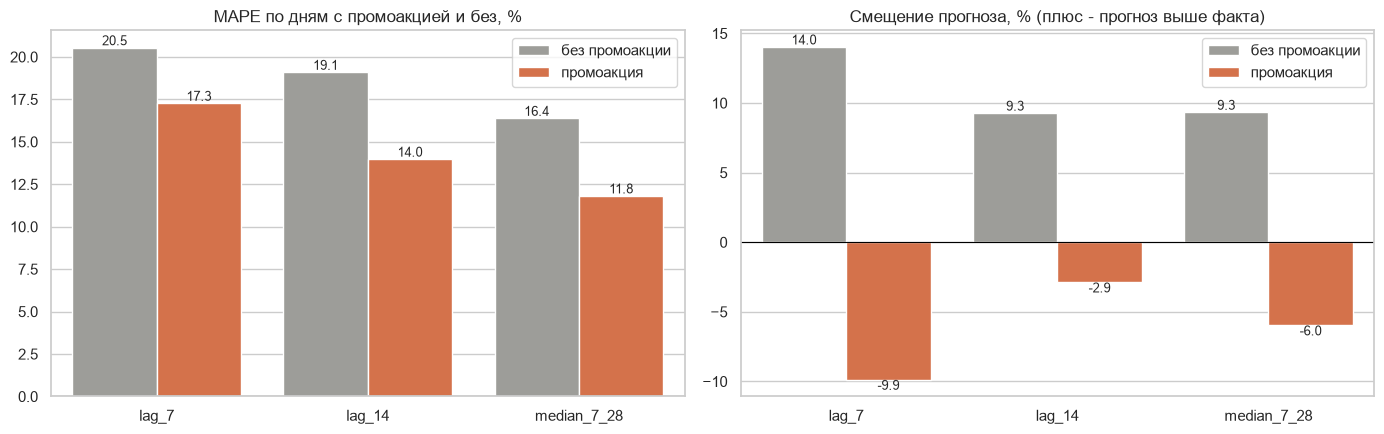

Смещение бейзлайнов по фолдам и наличию промоакции, %:


fold                  зима                     весна             \
промоакция  без промоакции промоакция без промоакции промоакция   
бейзлайн                                                          
lag_14                19.8       -3.0            0.8       -5.4   
lag_7                 20.2       -8.4           12.2      -11.6   
median_7_28           17.0       -3.1            4.1       -8.8   

fold                  лето             
промоакция  без промоакции промоакция  
бейзлайн                               
lag_14                 7.7        0.4  
lag_7                 10.5       -9.1  
median_7_28            7.4       -5.1

In [10]:
folds_days = pd.concat([period_days(calendar, f.start, f.end).assign(fold=f.name) for f in FOLDS])
y = folds_days["customers_clean"].astype(float)
errors = pd.concat([
    pd.DataFrame({"бейзлайн": name, "fold": folds_days["fold"],
                  "промоакция": folds_days["Promo"].map({0: "без промоакции", 1: "промоакция"}),
                  "APE, %": (baselines.loc[folds_days.index, name] - y).abs() / y * 100,
                  "смещение, %": (baselines.loc[folds_days.index, name] - y) / y * 100})
    for name in BASELINES
])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, column, title in [(axes[0], "APE, %", "MAPE по дням с промоакцией и без, %"),
                          (axes[1], "смещение, %", "Смещение прогноза, % (плюс - прогноз выше факта)")]:
    sns.barplot(data=errors, x="бейзлайн", y=column, hue="промоакция", errorbar=None, ax=ax,
                palette={"без промоакции": "#9e9d98", "промоакция": "#eb6834"})
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", fontsize=9)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set(title=title, xlabel="", ylabel="")
    ax.legend(title="")
plt.tight_layout()
plt.show()

# смещение по фолдам: не объясняется ли оно одним периодом
print("Смещение бейзлайнов по фолдам и наличию промоакции, %:")
(errors.groupby(["бейзлайн", "fold", "промоакция"])["смещение, %"].mean()
 .unstack(["fold", "промоакция"]).reindex(columns=["зима", "весна", "лето"], level=0).round(1))

Вывод раздела 3.2 ноутбука `02_eda` подтверждается: `lag_7` систематически занижает прогноз в дни с промоакцией - в среднем на 9.9%, и завышает его в дни без промоакции - на 14.0%. Это связано с тем, что неделю назад обычно была другая фаза промоакции. У `lag_14` смещение в дни с промоакцией значительно меньше (-2.9%), поскольку две недели назад чаще была та же фаза промоакции. У `median_7_28`, которая объединяет недели с промоакцией и без нее, смещение занимает промежуточное положение (-6.0%).

По фолдам видно, что завышение прогноза в дни без промоакции сильнее всего зимой: для разных бейзлайнов оно составляет около 17-20%. Вероятно, это связано не с промоакциями, а с календарным эффектом: январские значения прогнозируются по более высоким декабрьским значениям после рождественского пика. Весной и летом `lag_14` дает меньшее смещение, чем `lag_7`, как в дни с промоакцией, так и без нее.

Прямая проверка: сравним ошибку лагов в днях, когда фаза промоакции в день прогноза и в день, откуда взято значение, совпадает, и когда отличается.

In [11]:
promo = calendar["Promo"].astype(float)
rows = []
for name, weeks in [("lag_7", source_week), ("lag_14", source_week_14)]:
    # промоакция в тот день, из которого бейзлайн взял значение
    source_promo = pd.Series(np.nan, index=calendar.index)
    for k in weeks.loc[folds_days.index].dropna().unique():
        idx = folds_days.index[weeks.loc[folds_days.index] == k]
        source_promo.loc[idx] = promo.groupby(calendar["Store"]).shift(7 * int(k)).loc[idx]
    same_phase = promo.loc[folds_days.index] == source_promo.loc[folds_days.index]
    ape = errors.loc[errors["бейзлайн"] == name, "APE, %"]
    rows.append({"бейзлайн": name, "доля дней с той же фазой, %": same_phase.mean() * 100,
                 "MAPE при той же фазе, %": ape[same_phase].mean(),
                 "MAPE при другой фазе, %": ape[~same_phase].mean()})
pd.DataFrame(rows).set_index("бейзлайн").round(1)

,"доля дней с той же фазой, %","MAPE при той же фазе, %","MAPE при другой фазе, %"
бейзлайн,,,
lag_7,36.7,15.1,21.2
lag_14,74.0,13.6,25.3


У `lag_7` фаза промоакции совпадает только в 36.7% дней, у `lag_14` - в 74.0%. При совпадающей фазе оба лага ошибаются примерно одинаково (MAPE 15.1% и 13.6%), при несовпадающей - заметно сильнее (21.2% и 25.3%). Значит, преимущество `lag_14` не в самом лаге, а в том, что он чаще попадает в ту же фазу промоакции.

**Для модели:** значение лага нужно использовать вместе с информацией о промоакции - и в день прогноза, и в день, из которого взят лаг. Тогда модель сможет пересчитать значение из другой фазы промоакции, а не просто выбирать между лагами. Планка для модели - `median_7_28`: MAPE 14.6% и MAE 118.7 в среднем по фолдам.

## 3. Признаки

### 3.1 Построение признаков

Все признаки для дня `t` строятся только из информации, которая доступна на момент прогноза: либо из истории не позже `t - 7` (раздел 1.1), либо из заранее известного плана на день `t`.

Лаги и уровень покупателей используются в логарифме. В разделе 2 ноутбука `02_eda` показано, что сезонность мультипликативная. Поэтому модель прогнозирует не само количество покупателей, а отклонение от недавнего уровня.

**Уровень и целевая переменная:**

* `level` - среднее значение `log(покупатели)` за последние 24 открытых дня, доступных не позже `t - 7`. Это примерно 4 недели истории, в которых фазы промоакций в среднем сбалансированы;
* целевая переменная - `log(покупатели) - level`, то есть отклонение числа покупателей в конкретный день от недавнего уровня магазина. После прогноза значение возвращается в исходный масштаб: `exp(прогноз + level)`;
* `level_age` - сколько дней прошло от дня `t` до последнего открытого дня, вошедшего в расчет `level`, но не более 28. В обычной ситуации это 7 дней. После пропуска в данных или длительного закрытия магазина значение больше, то есть рассчитанный уровень становится менее свежим. Обоснование ограничения в 28 дней приведено в проверке ниже.

**Лаги:**

Все лаги описывают отклонение покупателей от `level` в прошлом:

* `lag_7`, `lag_14`, `lag_21`, `lag_28` - значение покупателей в тот же день недели 1-4 недели назад. Учитываются только открытые дни;
* `promo_lag_7`, ..., `promo_lag_28` - наличие промоакции в соответствующий день лага. Этот признак нужен, чтобы модель могла учитывать различия между днями с промоакцией и без нее (раздел 2);
* `lag_filled` и `lag_filled_weeks` - ближайшее доступное значение того же дня недели и количество недель назад, откуда оно взято. Если нужный день был закрыт или отсутствовал в данных, используется более старая неделя;
* `lag_median` - медиана значений за те же дни недели в предыдущие 1-4 недели. Этот признак соответствует бейзлайну, который показал наилучший результат в разделе 2;
* `rel_364` - значение целевой переменной ровно 52 недели назад, то есть отклонение того же дня недели год назад от уровня магазина в тот момент. Признак используется для учета годовой сезонности (раздел 5 ноутбука `02_eda`).

**Признаки, известные заранее для дня `t`:**

* `Promo`, `DayOfWeek`, `month`;
* `next_holiday` и `prev_holiday` - тип ближайшего государственного праздника и расстояние до него: до 3 дней до праздника и до 3 дней после него. Эти признаки позволяют учитывать перенос спроса на дни рядом с праздником (раздел 6 ноутбука `02_eda`);
* `easter_day` - положение дня относительно Пасхи, от -7 до +1 (раздел 5.3 ноутбука `02_eda`);
* `christmas_day` - положение в рождественском периоде с 1 декабря по 6 января (раздел 6.2 ноутбука `02_eda`);
* `carnival_day` - положение дня относительно карнавального понедельника, от -4 до +1. Карнавальный понедельник определяется как Пасха минус 48 дней. Эти даты совпадают с датами, найденными по закрытиям магазинов в разделе 6.4 ноутбука `02_eda`: 11.02.2013, 03.03.2014 и 16.02.2015;
* `days_since_reopen` - количество дней в первые 14 дней после длинного закрытия, от 0 до 13. Признак учитывает всплеск покупателей после открытия (раздел 1.4 ноутбука `02_eda`);
* `days_to_long_closure` - количество дней до длинного закрытия, от 1 до 7, рассчитанное по известному расписанию работы магазина;
* `segment` - сегмент магазина.

Признаки событий (`next_holiday`, `easter_day` и другие) используются как категориальные. Их влияние не обязательно меняется монотонно с расстоянием до события: например, пик спроса на Пасху может приходиться на конкретный день перед праздником. Поэтому для каждого значения признака модель оценивает отдельный эффект. Дни, которые не попадают в заданное окно события, получают значение `"нет"`.




## 3. Признаки

### 3.1 Построение признаков

Все признаки для дня t строятся либо из истории не позже t - 7 (раздел 1.1), либо из плана на день t. Лаги и уровень берутся в логарифме: сезонность мультипликативная (раздел 2 ноутбука `02_eda`), поэтому эффекты - это проценты от уровня магазина.

**Уровень и целевая:**
- `level` - среднее логарифма покупателей по последним 24 открытым дням не позже t - 7 (около 4 недель, фазы промоакций сбалансированы);
- целевая - `log(покупатели) - level`: отклонение дня от недавнего уровня магазина. Прогноз в покупателях - `exp(прогноз + level)`;
- `level_age` - сколько дней от t до последнего открытого дня в `level`, но не больше 28. Обычно это 7 дней, после пробела выгрузки или длинного закрытия - больше: уровень устарел. Почему значение ограничено, показано в проверке ниже.

**Лаги** (все - относительно `level`):
- `lag_7`, `lag_14`, `lag_21`, `lag_28` - тот же день недели 1-4 недели назад, только открытые дни, иначе пропуск;
- `promo_lag_7`, ..., `promo_lag_28` - была ли промоакция в день лага: без этого модель не может пересчитать лаг из другой фазы промоакции (раздел 2);
- `lag_filled` и `lag_filled_weeks` - ближайший доступный лаг того же дня недели и сколько недель назад он взят;
- `lag_median` - медиана лагов 1-4 недели назад (лучший бейзлайн раздела 2 как признак);
- `rel_364` - значение целевой ровно 52 недели назад: отклонение того же дня недели год назад от уровня магазина в то время (годовая сезонность, раздел 5 ноутбука `02_eda`).

**План на день t:**
- `Promo`, `DayOfWeek`, `month`;
- `next_holiday` и `prev_holiday` - тип ближайшего государственного праздника и сколько до него (после него) дней, если не больше 3: спрос переносится на соседние с праздником дни (раздел 6 ноутбука `02_eda`);
- `easter_day` - день относительно Пасхи от -7 до +1 (раздел 5.3 ноутбука `02_eda`);
- `christmas_day` - дата с 1 декабря по 6 января (раздел 6.2 ноутбука `02_eda`);
- `carnival_day` - день относительно карнавального понедельника от -4 до +1. Понедельник карнавала вычисляется как Пасха минус 48 дней: это те же даты, что найдены по закрытиям в разделе 6.4 ноутбука `02_eda` (11.02.2013, 03.03.2014, 16.02.2015);
- `days_since_reopen` - 0-13 дней после длинного закрытия (всплеск после открытия, раздел 1.4 ноутбука `02_eda`), `days_to_long_closure` - 1-7 дней до длинного закрытия (по плану работы);
- `segment` - сегмент магазина.

Признаки событий (`next_holiday`, `easter_day` и т.п.) - категориальные: их влияние немонотонно (например, пик Пасхи - в четверг перед Страстной пятницей), поэтому каждое значение получает свой эффект. Дни вне окна события получают значение "нет".

In [12]:
# признаки - функция пакета build_features (src/customers_prediction/features.py);
# она же используется при прогнозе (predict.py). Кроме набора раздела 3 она строит и кандидатов раздела 7.1
features = build_features(calendar, stores)
levels = category_levels(stores)            # фиксированные значения категориальных признаков
FEATURES = BASE_FEATURES                    # набор признаков раздела 3
NUMERIC = BASE_NUMERIC
assert features.index.equals(calendar.index)
print(f"Признаков: {len(FEATURES)} (числовых {len(NUMERIC)}, категориальных {len(FEATURES) - len(NUMERIC)})")

Признаков: 24 (числовых 14, категориальных 10)


Проверим, насколько признаки заполнены на открытых днях трейна, и как выглядят признаки событий на примере одного магазина вокруг Пасхи 2015 года.

In [13]:
train_open = features[(features["day_status"] == "open") & (features["Date"] <= TRAIN_END)]
coverage = pd.DataFrame({
    "пропусков, %": train_open[NUMERIC + ["target"]].isna().mean() * 100,
    "магазинов с пропусками": train_open[NUMERIC + ["target"]].isna().groupby(train_open["Store"]).any().sum(),
}).round(1)
display(coverage)

# level_age без ограничения: в трейне и в днях фолдов
last_known = (calendar["Date"].where(calendar["day_status"].eq("open") & calendar["customers_clean"].notna())
              .groupby(calendar["Store"]).shift(HORIZON).groupby(calendar["Store"]).ffill())
raw_age = (calendar["Date"] - last_known).dt.days
age_bins = pd.cut(raw_age[train_open.index], [0, 7, 14, 28, 60, 1000], labels=["7", "8-14", "15-28", "29-60", "больше 60"])
display(age_bins.value_counts(sort=False).rename("открытых дней трейна").to_frame())
long_age = train_open[raw_age[train_open.index].gt(60)]
print(f"level_age больше 60 дней: магазины {sorted(long_age['Store'].unique().tolist())}, "
      f"даты {long_age['Date'].min().date()} - {long_age['Date'].max().date()}, "
      f"значения {raw_age[long_age.index].min():.0f}-{raw_age[long_age.index].max():.0f} дней")
for column in ["next_holiday", "easter_day", "christmas_day", "carnival_day", "days_since_reopen"]:
    print(f"{column}: дней в окне события - {train_open[column].ne('нет').mean():.1%}")

example_store = int(features["Store"].iloc[0])
(features[(features["Store"] == example_store) & features["Date"].between("2015-03-28", "2015-04-08")]
 [["Date", "DayOfWeek", "day_status", "Promo", "next_holiday", "prev_holiday", "easter_day", "lag_7", "promo_lag_7", "target"]]
 .round({"lag_7": 3, "target": 3}))

,"пропусков, %",магазинов с пропусками
Promo,0.0,0
level_age,0.9,40
lag_filled,2.6,40
lag_filled_weeks,2.6,40
lag_median,2.6,40
rel_364,47.1,40
lag_7,5.7,40
lag_14,6.2,40
lag_21,6.3,40
lag_28,7.2,40


,открытых дней трейна
Date,
7,27491
8-14,857
15-28,21
29-60,15
больше 60,45


level_age больше 60 дней: магазины [81, 100, 186, 598, 736, 842, 902, 932, 977], даты 2015-01-02 - 2015-01-08, значения 186-192 дней
next_holiday: дней в окне события - 9.0%
easter_day: дней в окне события - 2.2%
christmas_day: дней в окне события - 7.9%
carnival_day: дней в окне события - 2.1%
days_since_reopen: дней в окне события - 0.4%


,Date,DayOfWeek,day_status,Promo,next_holiday,prev_holiday,easter_day,lag_7,promo_lag_7,target
816,2015-03-28,6,open,0.0,нет,нет,нет,-0.489,0.0,-0.477
817,2015-03-29,7,closed,0.0,нет,нет,-7,NaN,0.0,NaN
818,2015-03-30,1,open,1.0,нет,нет,-6,0.045,0.0,0.383
819,2015-03-31,2,open,1.0,b_3,нет,-5,0.031,0.0,0.373
820,2015-04-01,3,open,1.0,b_2,нет,-4,-0.088,0.0,0.203
821,2015-04-02,4,open,1.0,b_1,нет,-3,0.107,0.0,0.547
822,2015-04-03,5,closed,1.0,b_0,нет,-2,-0.022,0.0,NaN
823,2015-04-04,6,open,0.0,b_2,b_1,-1,-0.485,0.0,0.129
824,2015-04-05,7,closed,0.0,b_1,b_2,0,NaN,0.0,NaN
825,2015-04-06,1,closed,0.0,b_0,b_3,1,0.387,1.0,NaN


Пропуски в признаках в основном ожидаемы и связаны с особенностями построения признаков:

* `rel_364` отсутствует почти в половине дней трейна (47%): для всего 2013 года нет данных за предыдущий год, а у 9 магазинов дополнительно отсутствует часть истории из-за пробела в выгрузке;
* лаги отсутствуют в 6-7% дней, когда соответствующий день недели был закрыт из-за праздника или другого закрытия. При использовании `lag_filled` и `lag_median` доля пропусков снижается до 2.6%;
* целевая переменная отсутствует в 2.4% открытых дней трейна: это первые недели истории, когда для магазина еще недостаточно открытых дней для расчета уровня.

`level_age` почти всегда равен 7 дням: так происходит в 27 491 из 28 429 открытых дней трейна. Значения больше 28 дней встречаются только в 60 днях. В 45 из них это первая неделя января 2015 года у 9 магазинов с пробелом в выгрузке: уровень для них устарел на 186-192 дня. Значений между 60 и 186 днями нет.

Для таких больших значений в данных практически нет примеров, поэтому модель не может надежно выучить их влияние. Линейная модель при этом может экстраполировать зависимость далеко за пределы наблюдавшегося диапазона. Поэтому `level_age` ограничен 28 днями: для модели все более старые значения означают одно и то же - уровень сильно устарел.

Признаки событий встречаются редко: окно государственного праздника охватывает 9% открытых дней, рождественский период - 7.9%, Пасха и карнавал - около 2%, первые две недели после открытия - 0.4%. При этом даже редкие события могут быть важны для прогноза. Например, на неделе перед Пасхой 2015 года целевая переменная с понедельника по четверг была на 0.20-0.55 выше обычного уровня. В четверг перед Страстной пятницей значение достигло 1.7 уровня. `lag_7` такой рост не предсказывает. Часть повышения связана с промоакцией (около +0.18 в логарифмической шкале, см. раздел 3.2 ноутбука `02_eda`), но рост в четверг заметно превышает этот вклад. Поэтому модели нужны отдельные признаки календарных событий.

### 3.2 Проверка на утечку
Проверим правило из раздела 1.1 напрямую: удалим значения числа покупателей после даты прогноза и пересчитаем признаки. Если признаки для следующих 7 дней не изменились, значит, при их расчете не использовалась информация, которая на дату прогноза еще неизвестна.

Проверку проведем для начала каждого фолда и для начала отложенного периода.

In [14]:
history_columns = NUMERIC + ["level"]
for origin in [fold.start for fold in FOLDS] + [TEST_START]:
    wiped = calendar.copy()
    wiped.loc[wiped["Date"] >= origin, "customers_clean"] = pd.NA
    rebuilt = build_features(wiped, stores)
    week = features["Date"].between(origin, origin + pd.Timedelta(days=HORIZON - 1))
    pd.testing.assert_frame_equal(features.loc[week, history_columns], rebuilt.loc[week, history_columns])
    changed_after = (~np.isclose(features.loc[~week & (features["Date"] >= origin), "lag_7"],
                                 rebuilt.loc[~week & (features["Date"] >= origin), "lag_7"], equal_nan=True)).sum()
    print(f"Дата прогноза {origin.date()}: признаки 7 дней совпадают; "
          f"дальше горизонта изменились значения lag_7 в {changed_after} строках (как и должно быть)")

Дата прогноза 2014-12-06: признаки 7 дней совпадают; дальше горизонта изменились значения lag_7 в 7586 строках (как и должно быть)


Дата прогноза 2015-03-28: признаки 7 дней совпадают; дальше горизонта изменились значения lag_7 в 3967 строках (как и должно быть)


Дата прогноза 2015-05-09: признаки 7 дней совпадают; дальше горизонта изменились значения lag_7 в 2602 строках (как и должно быть)


Дата прогноза 2015-06-20: признаки 7 дней совпадают; дальше горизонта изменились значения lag_7 в 1225 строках (как и должно быть)


*Для всех четырех дат прогноза признаки 7 дней горизонта полностью совпадают с признаками, построенными без данных после даты прогноза. Дальше горизонта значения меняются (например, `lag_7` - в тысячах строк), то есть проверка чувствительна: если бы признак использовал будущее, она бы это показала. Утечки из будущего нет.

## 4. Линейная модель (Ridge)

Ridge - линейная регрессия с L2-регуляризацией: она уменьшает веса признаков и не дает модели переобучиться на коррелирующих лагах. Признаки те же, что у бустинга, но линейной модели нужна подготовка:
* пропуски в числовых признаках заполняются нулем. Для признаков, заданных относительно уровня магазина, это нейтральное значение, а отдельный индикатор пропуска позволяет модели отличать его от настоящего нулевого значения;
* числовые признаки масштабируются, чтобы их коэффициенты были сопоставимы по масштабу;
* категориальные признаки кодируются one-hot: каждое значение представляется отдельным бинарным признаком.

Для каждого фолда модель обучается на всех открытых днях до его начала, для которых известна целевая переменная. Силу регуляризации alpha выбираем по средней MAPE на трех фолдах. Для выбора нужен один критерий: если смотреть сразу на несколько метрик, они могут указать на разные значения. Основная метрика здесь - MAPE: модель обучается на целевой `log(покупатели / уровень магазина)`, то есть минимизирует относительную ошибку, а MAPE измеряет именно ее и дает всем магазинам одинаковый вес независимо от их размера. Средняя MAE в таблице приведена для проверки, что выбор не зависит от метрики. Все три метрики (MAE, MAPE и WAPE) приводятся в итоговом сравнении моделей: на фолдах (раздел 6.1) и на отложенном периоде (раздел 9.1).

In [15]:
ridge_grid = {}
for alpha in [0.1, 1, 10, 100, 1000]:
    pred = run_folds(features, calendar, lambda: make_ridge(levels, FEATURES, alpha), FEATURES)
    ridge_grid[alpha] = fold_scores(pred, calendar)
ridge_table = pd.DataFrame({alpha: {**{f"MAPE {fold}, %": s.loc[fold, "MAPE, %"] for fold in FOLD_NAMES},
                                    "MAPE среднее, %": s.loc["среднее", "MAPE, %"],
                                    "MAE среднее": s.loc["среднее", "MAE"]}
                            for alpha, s in ridge_grid.items()}).T.rename_axis("alpha")
RIDGE_ALPHA = ridge_table["MAPE среднее, %"].idxmin()
print(f"Выбрано alpha = {RIDGE_ALPHA}")
assert RIDGE_ALPHA == CONFIGURED_RIDGE_ALPHA, "выбор расходится с model.RIDGE_ALPHA"
ridge_table.round(2)

Выбрано alpha = 10.0


,"MAPE зима, %","MAPE весна, %","MAPE лето, %","MAPE среднее, %",MAE среднее
alpha,,,,,
0.1,18.88,7.73,7.60,11.40,97.70
1.0,18.79,7.72,7.59,11.37,97.19
10.0,18.59,7.74,7.55,11.29,95.42
100.0,20.76,8.08,7.54,12.13,99.44
1000.0,22.94,8.68,7.96,13.19,106.87


Выбрано `alpha = 10`: при этом значении одновременно достигаются минимальные средняя MAPE (11.29%) и средняя MAE (95.4 покупателя). Обе метрики поэтому дают один и тот же выбор.

**Как сила регуляризации влияет на качество.**

При `alpha` от 0.1 до 10 средняя MAPE почти не меняется: она находится в диапазоне 11.29-11.40%. В обучении участвуют десятки тысяч наблюдений, а после one-hot кодирования получается около 150 признаков. Данных достаточно, чтобы надежно оценить коэффициенты, поэтому слабая регуляризация почти не влияет на результат.

При `alpha = 100` и `1000` качество заметно ухудшается: средняя MAPE увеличивается до 12.13% и 13.19%. Почти весь рост ошибки приходится на зимний фолд: MAPE увеличивается с 18.6% до 20.8% и 22.9%, тогда как весной и летом разница составляет не более 1 п.п.

Вероятная причина - сильная регуляризация слишком сильно уменьшает коэффициенты редких признаков. Например, каждый день рождественского периода встречается в обучении всего один-два раза на магазин. При большом `alpha` модель сильнее притягивает их коэффициенты к нулю и поэтому слабее учитывает рождественский рост спроса. В результате особенно увеличивается ошибка на зимнем фолде.

**Сравнение с бейзлайнами.**

В среднем по фолдам Ridge показывает меньшую ошибку, чем лучший бейзлайн `median_7_28`: MAPE составляет 11.3% против 14.6%, а MAE - 95.4 против 118.7 покупателей.

Разница зависит от сезона. Весной и летом Ridge снижает MAPE примерно на треть: с 11.8% до 7.7% и с 10.6% до 7.6% соответственно. Зимой преимущество меньше: 18.6% против 21.3%, то есть ошибка снижается примерно на 13%.

Зимний фолд остается самым сложным. На него приходится рождественский период, а также первые дни после пробела в выгрузке у 9 магазинов, для которых недавней истории недостаточно. Поэтому в этот период как сезонные эффекты, так и проблемы с доступностью истории сильнее влияют на качество прогноза.


## 5. Градиентный бустинг (LightGBM)

LightGBM использует те же признаки, что и Ridge, но дополнительная подготовка данных не требуется: пропуски модель обрабатывает самостоятельно, а категориальные признаки передаются как категории.

Модель обучается на целевой переменной в логарифме. Используется квадратичная функция потерь, поэтому модель старается хорошо предсказывать относительный масштаб числа покупателей: ошибка в два раза больше и в два раза меньше исходного значения штрафуется примерно одинаково в логарифмической шкале.

Гиперпараметры подбираем по небольшой сетке и выбираем комбинацию с минимальной средней MAPE на трех фолдах:

* `num_leaves` - число листьев в дереве, которое определяет его сложность;
* `min_child_samples` - минимальное число наблюдений в листе, ограничивающее слишком детальные разбиения, особенно на редких событиях;
* `n_estimators` - число деревьев при фиксированном `learning_rate = 0.05`.

Раннюю остановку отдельно на каждом фолде не используем: в этом случае тот же фолд участвовал бы в выборе числа деревьев, а затем использовался бы для оценки качества. Это сделало бы оценку оптимистичной.

Вместо этого число деревьев включаем в сетку гиперпараметров. Модель один раз обучается на 1000 деревьев, после чего качество проверяется по прогнозам, полученным с использованием первых 150, 300, 600 и 1000 деревьев.

In [16]:
N_TREES = [150, 300, 600, 1000]

lgbm_rows = []
for num_leaves in [15, 31, 63]:
    for min_child_samples in [50, 100, 200, 400]:
        preds = {n: [] for n in N_TREES}
        for fold in FOLDS:
            train = training_rows(features, fold.start)
            test = features.loc[period_days(calendar, fold.start, fold.end).index]
            model = make_lgbm(levels, num_leaves, min_child_samples, max(N_TREES)).fit(train[FEATURES], train["target"])
            for n in N_TREES:
                relative = model.predict(test[FEATURES], num_iteration=n)
                preds[n].append(pd.DataFrame({"fold": fold.name, "pred": np.exp(relative + test["level"])},
                                             index=test.index))
        for n in N_TREES:
            s = fold_scores(pd.concat(preds[n]), calendar)
            lgbm_rows.append({"num_leaves": num_leaves, "min_child_samples": min_child_samples, "n_estimators": n,
                              **{f"MAPE {fold}, %": s.loc[fold, "MAPE, %"] for fold in FOLD_NAMES},
                              "MAPE среднее, %": s.loc["среднее", "MAPE, %"], "MAE среднее": s.loc["среднее", "MAE"]})

lgbm_table = pd.DataFrame(lgbm_rows).sort_values("MAPE среднее, %", ignore_index=True)
LGBM_PARAMS = lgbm_table.loc[0, ["num_leaves", "min_child_samples", "n_estimators"]].astype(int).to_dict()
print(f"Выбрано: {LGBM_PARAMS}")
print(f"Разброс средней MAPE по всей сетке: {lgbm_table['MAPE среднее, %'].min():.2f} - "
      f"{lgbm_table['MAPE среднее, %'].max():.2f}%")
assert LGBM_PARAMS == CONFIGURED_LGBM_PARAMS, "выбор расходится с model.LGBM_PARAMS"
lgbm_table.head(10).round(2)

Выбрано: {'num_leaves': 63, 'min_child_samples': 200, 'n_estimators': 150}
Разброс средней MAPE по всей сетке: 9.60 - 10.97%


,num_leaves,min_child_samples,n_estimators,"MAPE зима, %","MAPE весна, %","MAPE лето, %","MAPE среднее, %",MAE среднее
0,63,200,150,14.43,7.55,6.81,9.60,81.22
1,31,200,150,14.32,7.59,6.90,9.60,81.50
2,31,200,300,14.49,7.46,6.87,9.61,80.91
3,15,200,150,14.42,7.62,7.06,9.70,82.74
4,63,200,300,14.83,7.49,6.82,9.71,81.53
5,15,200,300,14.68,7.52,7.10,9.77,83.00
6,63,400,300,14.80,7.43,7.13,9.79,82.90
7,31,200,600,15.19,7.48,6.84,9.84,82.29
8,31,400,300,14.90,7.44,7.21,9.85,83.54
9,15,200,600,15.18,7.35,7.12,9.88,83.40


Выбрана конфигурация `num_leaves` = 63, `min_child_samples` = 200, 150 деревьев: средняя MAPE 9.60%, средняя MAE 81.2 покупателя.

**Сетка пологая, выбор среди лучших конфигураций почти не важен.** Три лучшие конфигурации совпадают по средней MAPE с точностью до 0.01 п.п. (9.60-9.61%), 10 лучших отличаются не больше чем на 0.3 п.п., а вся сетка из 48 конфигураций (3 x 4 x 4) - от 9.60% до 10.97%. По MAE лучшей была бы третья конфигурация (`num_leaves` = 31, `min_child_samples` = 200, 300 деревьев: 80.9 против 81.2), но разница - меньше 0.4%, поэтому выбор по MAPE не противоречит MAE.

Как влияет каждый гиперпараметр:
- **`min_child_samples` - главный параметр.** У всех 10 лучших конфигураций он 200 или 400, а значения 50 и 100 в них не встречаются. Крупный лист не может состоять из нескольких редких дней (например, одного рождественского дня нескольких магазинов), поэтому модель вынуждена объединять похожие дни и меньше запоминает случайные колебания истории;
- **`num_leaves` почти не важен:** среди 10 лучших есть все три значения (15, 31 и 63). При крупных листьях ограничение на размер листа сильнее, чем ограничение на число листьев;
- **число деревьев - компромисс между фолдами.** Больше деревьев немного улучшает весну, но ухудшает зиму: например, при `num_leaves` = 15 и `min_child_samples` = 200 переход от 300 к 600 деревьям уменьшает MAPE весной с 7.52% до 7.35%, но увеличивает зимой с 14.68% до 15.18%. Чем больше деревьев, тем детальнее модель повторяет закономерности прошлых лет, а рождественский период каждый год немного другой. Поэтому среди лучших - 150-300 деревьев, а 1000 деревьев нет ни разу. 150 деревьев - край сетки, но 300 дают практически тот же результат (9.61% против 9.60%), поэтому расширять сетку дальше не нужно.

**Сравнение с Ridge.** При тех же признаках и тех же фолдах LightGBM точнее: средняя MAPE 9.60% против 11.29%, MAE 81.2 против 95.4. Почти весь выигрыш приходится на зимний фолд (14.4% против 18.6%), весной и летом разница небольшая (7.55% против 7.74% и 6.81% против 7.55%). Значит, основное преимущество бустинга - в периоды, где эффект дня зависит от сочетания признаков (дата рождественского периода, день недели, промоакция, сегмент), а в обычные дни линейной модели почти достаточно.

Ограничение: гиперпараметры выбраны по тем же фолдам, на которых оценивается качество, поэтому средняя MAPE 9.60% немного оптимистична. Сетка пологая, так что это смещение мало; независимую оценку качества дает отложенный период (раздел 9).

## 6. Сравнение моделей

### 6.1 Метрики на фолдах

Сравниваем бейзлайны раздела 2 и обе модели с выбранными гиперпараметрами на одних и тех же открытых днях фолдов. Улучшение - на сколько процентов модель уменьшает среднюю по фолдам ошибку бейзлайна.

In [17]:
predictions = {name: baseline_folds(baselines, calendar, name) for name in BASELINES}
predictions["Ridge"] = run_folds(features, calendar, lambda: make_ridge(levels, FEATURES, RIDGE_ALPHA), FEATURES)
predictions["LightGBM"] = run_folds(features, calendar, lambda: make_lgbm(levels, **LGBM_PARAMS), FEATURES)
MODELS = list(predictions)

scores = pd.concat({name: fold_scores(pred, calendar) for name, pred in predictions.items()}, names=["модель", "fold"])
comparison = scores.unstack("fold").reindex(MODELS)
comparison = comparison.reindex(columns=pd.MultiIndex.from_product(
    [["MAE", "MAPE, %", "WAPE, %"], FOLD_NAMES + ["среднее"]]))
display(comparison.round(1))

mean_scores = scores.xs("среднее", level="fold")
improvement = pd.DataFrame({
    f"{metric} к {base}": (1 - mean_scores[metric] / mean_scores.loc[base, metric]) * 100
    for base in ["lag_7", "median_7_28"] for metric in ["MAE", "MAPE, %"]
}).loc[["Ridge", "LightGBM"]]
print("Улучшение средней по фолдам ошибки, %:")
improvement.round(1)

MAE                       MAPE, %                     WAPE, %  \
              зима  весна   лето среднее    зима весна  лето среднее    зима   
модель                                                                         
lag_7        192.4  159.4  120.1   157.3    23.7  19.1  14.9    19.2    21.3   
lag_14       204.5  117.5   95.4   139.1    25.3  13.9  12.0    17.1    22.7   
median_7_28  170.2  101.1   84.8   118.7    21.3  11.8  10.6    14.6    18.9   
Ridge        153.0   67.6   65.6    95.4    18.6   7.7   7.5    11.3    17.0   
LightGBM     120.6   65.3   57.8    81.2    14.4   7.6   6.8     9.6    13.4   

                                 
            весна  лето среднее  
модель                           
lag_7        18.4  14.0    17.9  
lag_14       13.5  11.1    15.8  
median_7_28  11.6   9.9    13.5  
Ridge         7.8   7.7    10.8  
LightGBM      7.5   6.7     9.2

Улучшение средней по фолдам ошибки, %:


,MAE к lag_7,"MAPE, % к lag_7",MAE к median_7_28,"MAPE, % к median_7_28"
модель,,,,
Ridge,39.3,41.2,19.6,22.4
LightGBM,48.4,50.1,31.6,34.1


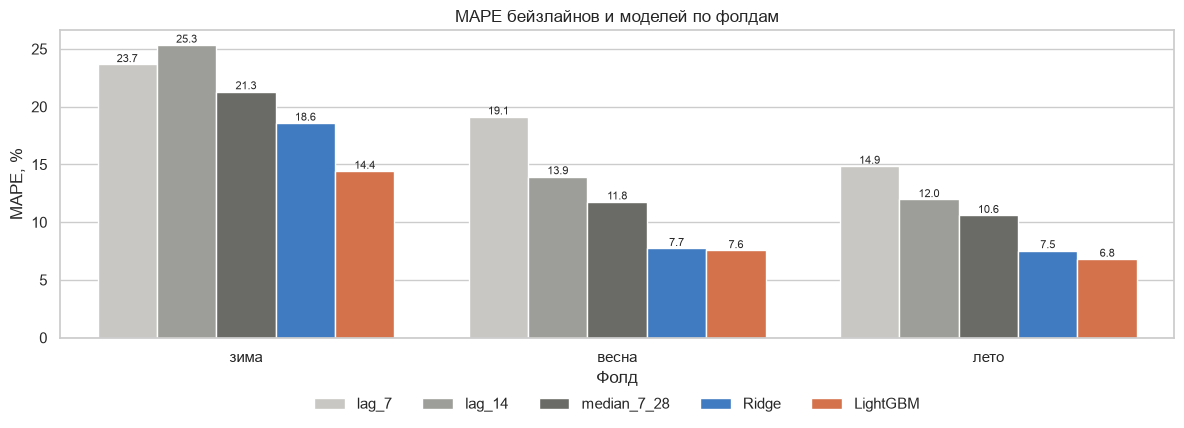

In [18]:
fig, ax = plt.subplots(figsize=(12, 4.5))
plot_data = scores.reset_index()
plot_data = plot_data[plot_data["fold"] != "среднее"]
palette = {"lag_7": "#c9c8c2", "lag_14": "#9e9d98", "median_7_28": "#6b6a66", "Ridge": "#2a78d6", "LightGBM": "#eb6834"}
sns.barplot(data=plot_data, x="fold", y="MAPE, %", hue="модель", hue_order=MODELS, palette=palette, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8)
ax.set(title="MAPE бейзлайнов и моделей по фолдам", xlabel="Фолд", ylabel="MAPE, %")
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(MODELS), frameon=False)
plt.tight_layout()
plt.show()

Обе модели лучше всех трех бейзлайнов в каждом фолде и по каждой из трех метрик. В среднем по фолдам:
- LightGBM: MAE 81.2, MAPE 9.6%, WAPE 9.2% - ошибка на 48% (MAE) и 50% (MAPE) меньше, чем у обязательного бейзлайна `lag_7`, и на 32% и 34% меньше, чем у лучшего бейзлайна `median_7_28`;
- Ridge: MAE 95.4, MAPE 11.3%, WAPE 10.8% - на 39% и 41% меньше, чем у `lag_7`, и на 20% и 22% меньше, чем у `median_7_28`.

**Метрики согласованы.** MAE, MAPE и WAPE дают один и тот же порядок: LightGBM, Ridge, `median_7_28`, `lag_14`, `lag_7` (у `lag_14` и `lag_7` порядок меняется только зимой). Значит, вывод о том, какая модель лучше, не зависит от выбора метрики. У бейзлайнов и LightGBM WAPE во всех фолдах ниже MAPE: в WAPE магазины весят пропорционально своему потоку, а относительная ошибка у мелких магазинов больше, чем у крупных. Сильнее всего разница зимой (у LightGBM 14.4% против 13.4%). У Ridge весной и летом наоборот, WAPE немного выше MAPE (7.8% против 7.7% и 7.7% против 7.5%): его относительные ошибки у крупных магазинов не меньше, чем у мелких.

**Улучшение по фолдам.** Относительно `median_7_28` LightGBM уменьшает MAPE почти одинаково во всех фолдах: примерно на 32% зимой, 36% весной и 36% летом. У Ridge улучшение весной и летом сопоставимое (около 35% и 29%), а зимой - только около 13%. То есть LightGBM сохраняет преимущество над бейзлайном и в самый сложный период, а у Ridge оно зимой в 2-3 раза меньше, чем в остальных фолдах.

**LightGBM против Ridge.** На тех же признаках LightGBM лучше, но преимущество неравномерно: зимой MAPE 14.4% против 18.6% и MAE 120.6 против 153.0 (на 21% меньше), а весной и летом разница небольшая: 7.6% против 7.7% и 6.8% против 7.5% по MAPE, 65.3 против 67.6 и 57.8 против 65.6 по MAE. В рождественский период эффект дня зависит от сочетания признаков (дата, день недели, промоакция, сегмент), и бустинг находит эти сочетания сам, а линейная модель складывает эффекты независимо. В обычные дни линейной модели почти достаточно.

**Сложность фолдов.** Зимний фолд остается самым трудным для всех моделей: даже у LightGBM MAPE зимой 14.4% - вдвое больше, чем весной и летом. В летнем фолде, ближайшем по условиям к отложенному периоду, LightGBM ошибается в среднем на 6.8% против 10.6% у лучшего бейзлайна.

### 6.2 Важность признаков LightGBM

Важность признака измеряется через gain - суммарное уменьшение функции потерь за счет всех разбиений по этому признаку. Для каждого признака считаем его долю от общего gain, затем усредняем полученные значения по моделям трех фолдов.

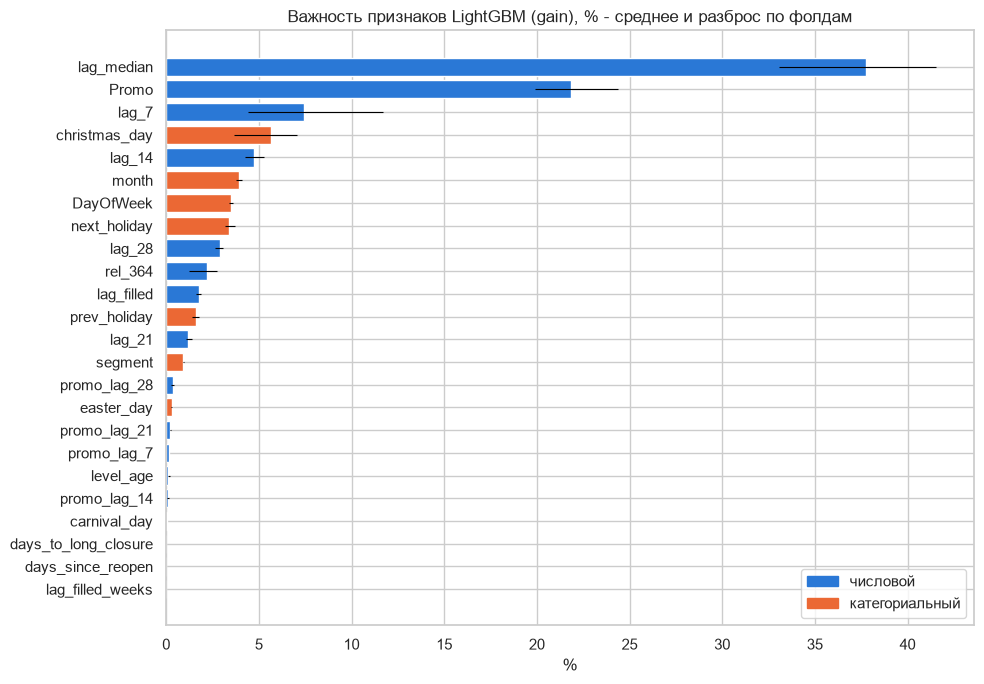

In [19]:
importance = {}
for fold in FOLDS:
    train = training_rows(features, fold.start)
    model = make_lgbm(levels, **LGBM_PARAMS).fit(train[FEATURES], train["target"])
    gain = pd.Series(model.named_steps["model"].booster_.feature_importance(importance_type="gain"), index=FEATURES)
    importance[fold.name] = gain / gain.sum() * 100
importance = pd.DataFrame(importance)
importance["среднее"] = importance.mean(axis=1)
importance = importance.sort_values("среднее")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance.index, importance["среднее"],
        color=["#eb6834" if f in CATEGORICAL else "#2a78d6" for f in importance.index])
ax.errorbar(importance["среднее"], importance.index,
            xerr=[importance["среднее"] - importance[FOLD_NAMES].min(axis=1),
                  importance[FOLD_NAMES].max(axis=1) - importance["среднее"]],
            fmt="none", color="black", linewidth=0.8)
ax.set(title="Важность признаков LightGBM (gain), % - среднее и разброс по фолдам", xlabel="%")
ax.legend(handles=[Patch(color="#2a78d6", label="числовой"), Patch(color="#eb6834", label="категориальный")],
          loc="lower right")
plt.tight_layout()
plt.show()

Наибольшую роль в LightGBM играют `lag_median` и `Promo`: на них приходится около 38% и 22% общего `gain` соответственно. Далее идут `lag_7`, `christmas_day`, `lag_14`, месяц, день недели и `next_holiday` - на каждый из этих признаков приходится примерно 3-7%.

Остальные признаки используются значительно реже. Это относится, в частности, к признакам промоакции в прошлые недели, карнавала, закрытий, `level_age` и `lag_filled_weeks`. Часть из них описывает редкие ситуации, поэтому модель получает мало возможностей использовать их для разбиений. Низкая важность признаков промоакции в прошлые недели может также означать, что информации о текущей `Promo` и обычных лагов уже достаточно. Это отдельно проверяется ниже.

Важность `lag_median` и `lag_7` заметно меняется от фолда к фолду. Эти признаки содержат похожую информацию и могут частично заменять друг друга: если один из них используется для разбиения, необходимость в другом снижается. Поэтому высокая или низкая важность отдельного лага не означает, что удаление именно этого признака обязательно ухудшит качество прогноза.


### 6.3 Абляция по группам признаков

Важность показывает, чем модель пользуется, но не то, насколько признаки улучшают прогноз: при коррелирующих признаках (например, разные лаги) модель может взять любой из них. Поэтому проверяем напрямую: убираем группу признаков, переобучаем обе модели на тех же фолдах и смотрим, насколько вырастает средняя MAPE.

In [20]:
FEATURE_GROUPS = {
    "лаги": ["lag_7", "lag_14", "lag_21", "lag_28", "lag_filled", "lag_filled_weeks", "lag_median"],
    "промоакции в дни лагов": PROMO_LAGS,
    "промоакция в день прогноза": ["Promo"],
    "год назад": ["rel_364"],
    "праздники и события": ["next_holiday", "prev_holiday", "easter_day", "christmas_day", "carnival_day"],
    "закрытия и возраст уровня": ["days_since_reopen", "days_to_long_closure", "level_age"],
    "день недели и месяц": ["DayOfWeek", "month"],
    "сегмент": ["segment"],
}
assert sorted(sum(FEATURE_GROUPS.values(), [])) == sorted(FEATURES), "группы должны покрывать все признаки"

full_mape = {"Ridge": mean_scores.loc["Ridge", "MAPE, %"], "LightGBM": mean_scores.loc["LightGBM", "MAPE, %"]}
ablation = {}
for group, columns in FEATURE_GROUPS.items():
    kept = [c for c in FEATURES if c not in columns]
    ablation[group] = {
        "Ridge": fold_scores(run_folds(features, calendar, lambda: make_ridge(levels, kept, RIDGE_ALPHA), kept),
                             calendar).loc["среднее", "MAPE, %"],
        "LightGBM": fold_scores(run_folds(features, calendar, lambda: make_lgbm(levels, **LGBM_PARAMS), kept),
                                calendar).loc["среднее", "MAPE, %"],
    }
ablation = pd.DataFrame(ablation).T
ablation_delta = (ablation - pd.Series(full_mape)).rename(columns=lambda c: f"{c}: рост MAPE, п.п.")
ablation_delta.sort_values("LightGBM: рост MAPE, п.п.", ascending=False).round(2)

,"Ridge: рост MAPE, п.п.","LightGBM: рост MAPE, п.п."
праздники и события,1.92,1.68
лаги,0.70,0.58
промоакция в день прогноза,1.11,0.42
день недели и месяц,0.40,0.39
год назад,0.27,0.19
сегмент,0.01,0.14
закрытия и возраст уровня,0.67,0.06
промоакции в дни лагов,-0.32,0.06


Сильнее всего прогноз ухудшается без праздников и событий: MAPE растет на 1.7 п.п. у LightGBM и на 1.9 п.п. у Ridge. Дальше идут лаги (0.6 и 0.7 п.п.), промоакция в день прогноза (0.4 и 1.1 п.п.), день недели и месяц (0.4 п.п. у обеих моделей) и год назад (0.2-0.3 п.п.). Группа закрытий и возраста уровня важна для Ridge (0.7 п.п.) и почти не важна для LightGBM (0.06 п.п.). Сегмент почти ничего не дает ни одной модели (0.14 и 0.01 п.п.): после перехода к целевой относительно уровня магазина различия сегментов в основном уже учтены.

Важность и абляция расходятся: `lag_median` - самый используемый признак, но без всех лагов MAPE вырастает только на 0.6 п.п. Уровень магазина уже задает базу прогноза, и модель может частично заменить лаги другими признаками.

Гипотеза раздела 2 о промоакции в дни лагов не подтвердилась: без этих признаков MAPE LightGBM меняется на 0.06 п.п., а Ridge без них даже становится лучше на 0.3 п.п. Модели не нужно пересчитывать лаг из другой фазы промоакции: целевая считается относительно уровня, в котором фазы промоакции сбалансированы, а эффект промоакции дня дает сам признак `Promo`. Какие признаки оставить в итоговой модели, решается в разделе 7 вместе с проверкой кандидатов.

## 7. Эксперименты

В этом разделе проверяем решения, которые были отложены в ноутбуке `02_eda` и в разделе 6: добавление новых признаков, обработку выбросов (которые не получилось объяснить) и обучение отдельных моделей для разных сегментов магазинов.

Все эксперименты проводим на основной модели LightGBM с гиперпараметрами из раздела 5 и на тех же трех фолдах. Это позволяет сравнивать результаты в одинаковых условиях.

**Правило принятия изменения:** изменение оставляем, если оно одновременно уменьшает среднюю MAPE по трем фолдам и улучшает MAPE как минимум в двух из трех фолдов. Второе условие нужно, чтобы не принимать решение только из-за улучшения на одном конкретном фолде.


In [21]:
# прогноз на фолдах (run_folds) и правило принятия (compare_to_base) - функции пакета
# (src/customers_prediction/validation.py)
def lgbm_folds(columns: list[str], **kwargs) -> pd.DataFrame:
    '''LightGBM с гиперпараметрами раздела 5 на фолдах; kwargs - train_target и rows для run_folds.'''
    return run_folds(features, calendar, lambda: make_lgbm(levels, **LGBM_PARAMS), columns, **kwargs)

### 7.1 Дополнительные признаки

Проверяем признаки, которые были предложены по результатам ноутбука `02_eda` и анализа важности признаков в разделе 6.3:

* `day_of_month` - день месяца. Проверяет гипотезу о возможном эффекте конца месяца, выявленном в разделе 7.4 ноутбука `02_eda`;
* `SchoolHoliday` - наличие школьных каникул. Этот признак известен заранее на дату прогноза;
* `Assortment` - тип ассортимента магазина;
* признаки конкурента: `competition_open` - открыт ли конкурент на дату `t`, и `competition_distance_log` - логарифм расстояния до ближайшего конкурента;
* `promo2_active` - действует ли у магазина программа Promo2 на дату `t`;
* `store_id` - номер магазина, переданный как категориальный признак. Он позволяет модели учитывать индивидуальные особенности магазинов, но при этом создает риск переобучения;
* удаление признаков, описывающих наличие промоакции в дни лагов. В разделе 6.3 они практически не использовались и не показали заметного вклада в прогноз.

Каждый кандидат проверяется отдельно: к базовому набору признаков из раздела 3 добавляется новый признак или удаляется проверяемая группа признаков, после чего результат сравнивается с базовой моделью.

In [22]:
# признаки-кандидаты уже построены функцией build_features (src/customers_prediction/features.py)
CANDIDATES = {
    "+ день месяца": ["day_of_month"],
    "+ школьные каникулы": ["SchoolHoliday"],
    "+ ассортимент": ["Assortment"],
    "+ конкурент": ["competition_open", "competition_distance_log"],
    "+ Promo2": ["promo2_active"],
    "+ магазин как категория": ["store_id"],
    "- промоакции в дни лагов": PROMO_LAGS,
}

base_scores = fold_scores(lgbm_folds(FEATURES), calendar)
candidate_rows = {}
for name, columns in CANDIDATES.items():
    variant = ([c for c in FEATURES if c not in columns] if name.startswith("-") else FEATURES + columns)
    candidate_rows[name] = compare_to_base(fold_scores(lgbm_folds(variant), calendar), base_scores)
candidate_table = pd.DataFrame(candidate_rows).T.infer_objects()
print(f"База (признаки раздела 3): средняя MAPE {base_scores.loc['среднее', 'MAPE, %']:.2f}%")
candidate_table.round(2)

База (признаки раздела 3): средняя MAPE 9.60%


,"изменение MAPE зима, п.п.","изменение MAPE весна, п.п.","изменение MAPE лето, п.п.","изменение MAPE среднее, п.п.",фолдов с улучшением,принять
+ день месяца,-0.06,-0.16,-0.12,-0.11,3,True
+ школьные каникулы,-0.03,0.06,-0.09,-0.02,2,True
+ ассортимент,-0.07,-0.08,-0.02,-0.06,3,True
+ конкурент,-0.33,-0.18,-0.13,-0.22,3,True
+ Promo2,0.09,0.01,0.04,0.04,0,False
+ магазин как категория,-1.21,-0.70,-0.33,-0.75,3,True
- промоакции в дни лагов,0.20,-0.06,0.05,0.06,1,False


Принятые изменения проверяем вместе: эффекты признаков могут пересекаться, поэтому итоговый набор должен быть лучше базы и сам по себе.

In [23]:
accepted = candidate_table.index[candidate_table["принять"].astype(bool)].tolist()
added = [c for name in accepted if name.startswith("+") for c in CANDIDATES[name]]
removed = [c for name in accepted if name.startswith("-") for c in CANDIDATES[name]]
FINAL_FEATURES = [c for c in FEATURES if c not in removed] + added
print(f"Принятые изменения: {accepted if accepted else 'нет'}")
print(f"Признаков в итоговом наборе: {len(FINAL_FEATURES)}")

if accepted:
    combined = compare_to_base(fold_scores(lgbm_folds(FINAL_FEATURES), calendar), base_scores)
    print(f"Все принятые изменения вместе: изменение средней MAPE {combined['изменение MAPE среднее, п.п.']:.2f} п.п., "
          f"улучшение в {combined['фолдов с улучшением']} фолдах из 3")
    if not combined["принять"]:
        FINAL_FEATURES = FEATURES
        print("Вместе изменения не проходят правило принятия - оставляем набор раздела 3")
assert FINAL_FEATURES == CONFIGURED_FEATURES, "итоговый набор расходится с features.FINAL_FEATURES"

Принятые изменения: ['+ день месяца', '+ школьные каникулы', '+ ассортимент', '+ конкурент', '+ магазин как категория']
Признаков в итоговом наборе: 30


Все принятые изменения вместе: изменение средней MAPE -0.94 п.п., улучшение в 3 фолдах из 3


Из 7 проверенных изменений правило принятия прошли 5.

**Принятые изменения.**

* `store_id` дает самое большое улучшение: средняя MAPE снижается на 0.75 п.п., причем улучшение есть во всех трех фолдах, а сильнее всего - зимой (на 1.2 п.п.). Это согласуется с разделом 3.3 ноутбука `02_eda`: недельный профиль у каждого магазина свой, и признака сегмента недостаточно, чтобы его описать. Номер магазина позволяет модели учесть такие индивидуальные особенности;
* признаки конкурента снижают среднюю MAPE на 0.22 п.п., день месяца - на 0.11 п.п., тип ассортимента - на 0.06 п.п. Все три изменения улучшают прогноз во всех трех фолдах. Улучшение от дня месяца согласуется с гипотезой об эффекте конца месяца из раздела 7.4 ноутбука `02_eda`;
* школьные каникулы прошли правило с минимальным запасом: средняя MAPE снижается всего на 0.02 п.п., а улучшение есть только в двух фолдах из трех (весной MAPE даже немного растет). Такой эффект находится на уровне случайных колебаний, поэтому признак оставлен формально по правилу, но его польза не доказана.

**Отклоненные изменения.**

* `promo2_active` ухудшает прогноз во всех трех фолдах (средняя MAPE растет на 0.04 п.п.). Это согласуется с разделами 4.4 и 8.3 ноутбука `02_eda`, где влияние программы Promo2 на спрос не обнаружено;
* удаление признаков промоакции в дни лагов (`promo_lag_*`) улучшает прогноз только весной, а в среднем ухудшает его на 0.06 п.п. Поэтому эти признаки остаются в модели, хотя по абляции в разделе 6.3 их вклад был почти незаметен.

**Проверка всех принятых изменений вместе.** Эффекты разных признаков могут пересекаться, поэтому принятые изменения дополнительно проверены вместе. Вместе они снижают среднюю MAPE на 0.94 п.п. (с 9.60% до 8.66%) и улучшают прогноз во всех трех фолдах. Итоговый набор состоит из 30 признаков.

### 7.2 Выбросы без объяснения

В разделе 7.5 ноутбука `02_eda` для выбросов без объяснения оставлены два варианта обучения: оставить как есть или ограничить отклонение от эталона уровнем порога. Метрики в любом случае считаются по реальным значениям.

Выбросы ищем тем же методом, что в разделе 7.1 ноутбука `02_eda`: отклонение от медианы 5 таких же соседних дней (тот же магазин, день недели и фаза промоакции), нормированное на робастный разброс магазина, порог |z| > 5. Выброс считается объясненным, если день попадает в окно события из признаков раздела 3 (праздник, Пасха, Рождество, карнавал, открытие после закрытия или неделя до закрытия); окна праздников и Рождества здесь немного шире, чем в ноутбуке `02_eda`. Чтобы не заглядывать в будущее, для каждого фолда выбросы ищутся только по данным до его начала.

In [24]:
Z_THRESHOLD = 5
EVENT_COLUMNS = ["next_holiday", "prev_holiday", "easter_day", "christmas_day", "carnival_day",
                 "days_since_reopen", "days_to_long_closure"]
in_event = features[EVENT_COLUMNS].ne("нет").any(axis=1)


def clipped_target(before: pd.Timestamp) -> tuple[pd.Series, pd.Series]:
    '''Целевая для обучения, где выбросы без объяснения ограничены порогом |z| = Z_THRESHOLD.
    Выбросы ищутся только по открытым дням до даты before. Возвращает целевую и флаг измененных дней.'''
    days = calendar[(calendar["day_status"] == "open") & (calendar["Date"] < before)].sort_values("Date")
    customers = days["customers_clean"].astype(float)
    reference = (customers.groupby([days["Store"], days["DayOfWeek"], days["Promo"]])
                 .transform(lambda s: s.rolling(5, center=True, min_periods=3).median()))
    log_ratio = np.log(customers / reference)
    center = log_ratio.groupby(days["Store"]).transform("median")
    scale = 1.4826 * (log_ratio - center).abs().groupby(days["Store"]).transform("median")
    z = (log_ratio - center) / scale
    to_clip = (z.abs() > Z_THRESHOLD) & ~in_event.loc[days.index]
    clipped_log = np.log(reference) + center + np.sign(z) * Z_THRESHOLD * scale
    target = features["target"].copy()
    changed = to_clip[to_clip].index
    target.loc[changed] = clipped_log.loc[changed] - features.loc[changed, "level"]
    return target, pd.Series(features.index.isin(changed), index=features.index)


clipped = {fold.name: clipped_target(fold.start) for fold in FOLDS}
for fold in FOLDS:
    target, changed = clipped[fold.name]
    train_rows = features["target"].notna() & (features["Date"] < fold.start)
    print(f"Фолд {fold.name}: ограничено {changed.sum()} дней обучения ({changed[train_rows].mean():.1%}), "
          f"из них вниз {(target[changed] > features.loc[changed, 'target']).sum()}")

clip_scores = fold_scores(lgbm_folds(FINAL_FEATURES, train_target=lambda fold: clipped[fold.name][0]), calendar)
final_base_scores = fold_scores(lgbm_folds(FINAL_FEATURES), calendar)
clip_decision = compare_to_base(clip_scores, final_base_scores)
CLIP_OUTLIERS = clip_decision["принять"]
print(f"Ограничивать выбросы при обучении: {'да' if CLIP_OUTLIERS else 'нет'}")
pd.Series({k: round(v, 2) if isinstance(v, float) else v for k, v in clip_decision.items()}).to_frame("ограничение выбросов")

Фолд зима: ограничено 131 дней обучения (0.6%), из них вниз 84
Фолд весна: ограничено 142 дней обучения (0.5%), из них вниз 98
Фолд лето: ограничено 143 дней обучения (0.5%), из них вниз 100


Ограничивать выбросы при обучении: нет


,ограничение выбросов
"изменение MAPE зима, п.п.",0.19
"изменение MAPE весна, п.п.",-0.06
"изменение MAPE лето, п.п.",-0.02
"изменение MAPE среднее, п.п.",0.04
фолдов с улучшением,2
принять,False


В каждом фолде метод находит среди дней обучения 131-143 выброса без объяснения, это 0.5-0.6% дней. Примерно две трети из них - выбросы вниз, как и в разделе 7.2 ноутбука `02_eda`.

Ограничение этих выбросов при обучении не проходит правило принятия. Весной и летом средняя MAPE почти не меняется (снижается на 0.06 и 0.02 п.п.), а зимой, наоборот, растет на 0.19 п.п. В результате средняя MAPE по трем фолдам увеличивается на 0.04 п.п. Хотя улучшение есть в двух фолдах из трех, первое условие правила - снижение средней MAPE - не выполняется.

Вероятная причина в том, что таких выбросов слишком мало, чтобы заметно сдвинуть модель. Кроме того, их влияние уже ограничено самой постановкой: целевая переменная в логарифмической шкале сжимает большие отклонения, а крупные листья (`min_child_samples = 200`) не дают модели подстраиваться под отдельные необычные дни.

Поэтому модель обучается на данных как есть, без ограничения выбросов.

### 7.3 Модели по сегментам

Проверяем вариант 4 из ноутбука `01_data_research`: отдельная модель LightGBM для каждого сегмента против общей модели. Сравниваем на днях каждого сегмента отдельно; отдельная модель выбирается для сегмента, если она проходит правило принятия.

In [25]:
def final_target(fold):
    return clipped[fold.name][0] if CLIP_OUTLIERS else features["target"]


global_pred = lgbm_folds(FINAL_FEATURES, train_target=final_target)
segment_rows = {}
SEGMENT_MODELS = []
for segment in ["mid", "high_check", "high_traffic"]:
    in_segment = lambda frame, segment=segment: frame["segment"] == segment
    own = fold_scores(lgbm_folds(FINAL_FEATURES, train_target=final_target, rows=in_segment), calendar)
    shared = fold_scores(global_pred[features.loc[global_pred.index, "segment"] == segment], calendar)
    decision = compare_to_base(own, shared)
    segment_rows[segment] = {"магазинов": int((selected["segment"] == segment).sum()),
                             "MAPE общей модели, %": shared.loc["среднее", "MAPE, %"],
                             "MAPE отдельной модели, %": own.loc["среднее", "MAPE, %"], **decision}
    if decision["принять"]:
        SEGMENT_MODELS.append(segment)
print(f"Отдельные модели для сегментов: {SEGMENT_MODELS if SEGMENT_MODELS else 'нет'}")
assert tuple(SEGMENT_MODELS) == CONFIGURED_SEGMENT_MODELS, "выбор расходится с model.SEGMENT_MODELS"
pd.DataFrame(segment_rows).T.infer_objects().round(2)

Отдельные модели для сегментов: ['high_check']


,магазинов,"MAPE общей модели, %","MAPE отдельной модели, %","изменение MAPE зима, п.п.","изменение MAPE весна, п.п.","изменение MAPE лето, п.п.","изменение MAPE среднее, п.п.",фолдов с улучшением,принять
mid,24,8.66,9.13,1.50,-0.12,0.04,0.47,1,False
high_check,11,8.06,7.93,-0.85,-0.08,0.52,-0.14,2,True
high_traffic,5,9.68,10.36,-0.02,1.15,0.89,0.68,1,False


Отдельная модель прошла правило принятия только для сегмента `high_check`. Для него средняя MAPE снижается на 0.14 п.п. (с 8.06% до 7.93%): зимой отдельная модель лучше общей на 0.85 п.п., весной - на 0.08 п.п. Но летом, в фолде, ближайшем по условиям к отложенному периоду, отдельная модель хуже общей на 0.52 п.п. Решение держится в основном на зимнем фолде, поэтому его запас небольшой.

Для сегментов `mid` и `high_traffic` отдельные модели хуже общей: средняя MAPE растет на 0.47 и 0.68 п.п. соответственно, а улучшение есть только в одном фолде из трех. Для `high_traffic` это ожидаемо: в сегменте всего 5 магазинов, и отдельной модели не хватает данных для обучения.

Общая модель выигрывает за счет того, что обучается на всех 40 магазинах сразу, а различия между сегментами и отдельными магазинами получает через признаки `segment` и `store_id`.

Итог: для сегмента `high_check` используется отдельная модель, для остальных сегментов - общая.

### 7.4 Итоговая конфигурация

Собираем все принятые решения и сравниваем итоговые модели с моделями раздела 6 на тех же фолдах. Ridge получает тот же итоговый набор признаков и ту же обработку выбросов, чтобы сравнение оставалось на одних и тех же признаках.

In [26]:
# итоговая модель - GuestForecaster (src/customers_prediction/model.py): общий LightGBM
# и отдельные модели для сегментов из SEGMENT_MODELS; ее сохраняет train.py и использует predict.py
predictions["LightGBM итоговый"] = run_folds(
    features, calendar, lambda: GuestForecaster(FINAL_FEATURES, levels, LGBM_PARAMS, tuple(SEGMENT_MODELS)),
    FINAL_FEATURES, train_target=final_target)
predictions["Ridge итоговый"] = run_folds(features, calendar, lambda: make_ridge(levels, FINAL_FEATURES, RIDGE_ALPHA),
                                          FINAL_FEATURES, train_target=final_target)

final_scores = pd.concat({name: fold_scores(predictions[name], calendar)
                          for name in ["median_7_28", "Ridge", "Ridge итоговый", "LightGBM", "LightGBM итоговый"]},
                         names=["модель", "fold"])
final_scores["MAPE, %"].unstack("fold")[FOLD_NAMES + ["среднее"]].round(2)

fold,зима,весна,лето,среднее
модель,,,,
median_7_28,21.31,11.77,10.60,14.56
Ridge,18.59,7.74,7.55,11.29
Ridge итоговый,18.47,7.73,7.54,11.25
LightGBM,14.43,7.55,6.81,9.60
LightGBM итоговый,12.87,6.65,6.32,8.62


Итоговая конфигурация LightGBM включает 30 признаков, обучение на данных без ограничения выбросов и отдельную модель для сегмента `high_check`. По сравнению с моделью из раздела 6 она снижает среднюю MAPE с 9.60% до 8.62% и лучше во всех трех фолдах:

* зимой - 12.87% против 14.43%;
* весной - 6.65% против 7.55%;
* летом - 6.32% против 6.81%.

Сильнее всего улучшение зимой, в самом сложном фолде.

Ridge на итоговом наборе признаков почти не меняется: средняя MAPE 11.25% против 11.29%. Основной выигрыш LightGBM дал `store_id`. Вероятно, линейная модель получает от номера магазина только постоянную поправку к уровню магазина, а LightGBM может учитывать особенности магазина в сочетании с другими признаками, например с днем недели.

Из-за этого разрыв между моделями увеличился: итоговый LightGBM ошибается в среднем на 8.62%, а Ridge - на 11.25%.

## 8. Альтернативный подход к сезонности: SARIMAX

SARIMAX из `statsmodels` - регрессия с ошибками ARIMA, отдельная модель для каждого магазина. Сезонность и события задаются явными регрессорами, а ARIMA-часть описывает, как отклонения от них сохраняются во времени: модель сама подстраивается под текущий уровень магазина по последним наблюдениям.

**Ряд:** логарифм покупателей в открытые дни; закрытые дни, пробелы выгрузки и периоды, когда точки нет, - пропуски (фильтр Калмана их пропускает).

**Регрессоры** - те же знания, что у LightGBM, но в виде, удобном для линейной модели с небольшим числом параметров на магазин:
- день недели (фиктивные переменные), промоакция;
- дни до и после государственного праздника (1-3 дня);
- неделя перед Пасхой (понедельник-четверг) и суббота перед Пасхой;
- рождественский период: 17-23 декабря, короткие дни 24 и 31 декабря, 27-30 декабря, 2-6 января;
- карнавал, 2 недели после длинного закрытия, неделя до длинного закрытия;
- годовая сезонность - две пары гармоник (синус и косинус дня года).

**Схема прогноза.** Параметры оцениваются один раз на данных до начала фолда. Для каждой недели фолда модель с этими параметрами пропускает через фильтр всю историю до начала недели и прогнозирует 7 дней вперед. В отличие от LightGBM, SARIMAX для дня t использует данные до вчерашнего дня относительно даты прогноза, а не только до t - 7, - это небольшое преимущество в свежести данных.

Сравниваем две спецификации ARIMA-части:
- ARMA(1, 1) - отклонения от регрессоров постепенно затухают, у каждого дня недели свой постоянный уровень;
- ARIMA(1, 1, 1) - уровень магазина может смещаться (случайное блуждание), подходит для сдвигов уровня после ремонта или открытия конкурента.

In [27]:
# регрессоры и прогноз SARIMAX по магазину - src/customers_prediction/sarimax.py
print("Регрессоры:", ", ".join(sarimax_exog(features).columns))

Регрессоры: dow_1, dow_2, dow_3, dow_4, dow_5, dow_6, dow_7, promo, before_holiday, after_holiday, easter_week, easter_saturday, pre_christmas, short_day, between_holidays, early_january, carnival, after_reopen, before_closure, sin_1, cos_1, sin_2, cos_2


In [28]:
import time

sarimax_fold_preds = {}
started = time.time()
for spec, order in SARIMAX_SPECS.items():
    parts = []
    for fold in FOLDS:
        pred = forecast_period(order, fold.start, fold.end, features, calendar)
        parts.append(pd.DataFrame({"fold": fold.name, "pred": pred}))
    sarimax_fold_preds[spec] = pd.concat(parts)
print(f"Время оценки SARIMAX: {(time.time() - started) / 60:.1f} мин")

for spec, pred in sarimax_fold_preds.items():
    bad = pred["pred"].isna() | ~np.isfinite(pred["pred"])
    print(f"{spec}: дней без прогноза - {bad.sum()}")

sarimax_scores = pd.concat({spec: fold_scores(pred, calendar) for spec, pred in sarimax_fold_preds.items()}, names=["модель", "fold"])
SARIMAX_SPEC = sarimax_scores.xs("среднее", level="fold")["MAPE, %"].idxmin()
print(f"Выбрана спецификация: {SARIMAX_SPEC}")
predictions["SARIMAX"] = sarimax_fold_preds[SARIMAX_SPEC]
sarimax_scores.unstack("fold").reindex(columns=pd.MultiIndex.from_product(
    [["MAE", "MAPE, %", "WAPE, %"], FOLD_NAMES + ["среднее"]])).round(1)

Время оценки SARIMAX: 20.2 мин
ARMA(1, 1): дней без прогноза - 0
ARIMA(1, 1, 1): дней без прогноза - 0
Выбрана спецификация: ARIMA(1, 1, 1)


MAE                     MAPE, %                    WAPE, %  \
                 зима весна  лето среднее    зима весна лето среднее    зима   
модель                                                                         
ARMA(1, 1)      104.8  66.6  68.3    79.9    11.9   7.4  8.2     9.2    11.6   
ARIMA(1, 1, 1)  105.1  63.1  64.4    77.5    12.1   7.1  7.9     9.0    11.6   

                                   
               весна лето среднее  
модель                             
ARMA(1, 1)       7.7  8.0     9.1  
ARIMA(1, 1, 1)   7.3  7.5     8.8

In [29]:
compare_models = ["lag_7", "median_7_28", "Ridge итоговый", "LightGBM итоговый", "SARIMAX"]
fold_comparison = pd.concat({name: fold_scores(predictions[name], calendar) for name in compare_models}, names=["модель", "fold"])
display(fold_comparison["MAPE, %"].unstack("fold")[FOLD_NAMES + ["среднее"]].round(2))

# по сегментам: средняя по фолдам MAPE
y_folds = calendar["customers_clean"].astype(float)
segment_mape = pd.DataFrame({
    name: ((predictions[name]["pred"] - y_folds.loc[predictions[name].index]).abs() / y_folds.loc[predictions[name].index] * 100)
    .groupby([features.loc[predictions[name].index, "segment"], predictions[name]["fold"]]).mean().groupby(level=0).mean()
    for name in compare_models})
segment_mape.round(2)

fold,зима,весна,лето,среднее
модель,,,,
lag_7,23.66,19.13,14.86,19.22
median_7_28,21.31,11.77,10.60,14.56
Ridge итоговый,18.47,7.73,7.54,11.25
LightGBM итоговый,12.87,6.65,6.32,8.62
SARIMAX,12.07,7.06,7.95,9.03


,lag_7,median_7_28,Ridge итоговый,LightGBM итоговый,SARIMAX
segment,,,,,
high_check,20.14,14.04,10.34,7.93,8.96
high_traffic,16.89,14.20,11.55,9.68,10.63
mid,19.46,14.89,11.68,8.66,8.59


**Выбор спецификации.** Лучшей оказалась ARIMA(1, 1, 1): средняя MAPE 9.0% против 9.2% у ARMA(1, 1), средняя MAE 77.5 против 79.9. ARIMA(1, 1, 1) лучше весной и летом, а зимой модели почти равны (12.1% и 11.9%). Вероятно, модель, в которой уровень магазина может смещаться, лучше подстраивается под текущий уровень магазина. Прогноз получен для всех дней, но оценка обеих спецификаций на трех фолдах заняла около 20 минут, тогда как LightGBM обучается за секунды.

**Сравнение с другими моделями.** SARIMAX - сильная альтернатива. Он заметно лучше всех бейзлайнов и Ridge: средняя MAPE 9.0% против 14.6% у лучшего бейзлайна `median_7_28` и 11.3% у Ridge. С итоговым LightGBM результаты близки, но модели сильны в разных условиях:

* зимой SARIMAX лучше LightGBM: 12.1% против 12.9%. В рождественский период спрос быстро меняется, и SARIMAX выигрывает от более свежих данных: он использует историю до дня перед датой прогноза, а LightGBM - только до `t - 7`;
* весной и летом лучше LightGBM: 6.7% против 7.1% и 6.3% против 8.0%;
* по сегментам в `mid` модели практически равны (8.59% у SARIMAX и 8.66% у LightGBM), а в `high_check` и `high_traffic` LightGBM лучше (7.9% против 9.0% и 9.7% против 10.6%).

В среднем по фолдам LightGBM точнее (8.6% против 9.0%), поэтому основной моделью остается LightGBM. SARIMAX используется как альтернативный подход к сезонности в финальном сравнении.

## 9. Финальное сравнение на отложенном периоде

Все решения приняты по фолдам в разделах 2-8 и дальше не меняются. Модели обучаются на всех данных трейна (до 19.06.2015) с итоговой конфигурацией и прогнозируют отложенный период 20.06-31.07.2015 шестью последовательными недельными прогнозами (раздел 1.1). Все модели сравниваются на одних и тех же 1470 открытых днях; закрытые дни прогнозируются нулем по правилу и в метрики не входят.

### 9.1 Метрики

In [30]:
holdout_days = period_days(calendar, TEST_START, HOLDOUT_END)
y_holdout = holdout_days["customers_clean"].astype(float)
holdout_target = clipped_target(TEST_START)[0] if CLIP_OUTLIERS else features["target"]
train_all = training_rows(features, TEST_START, holdout_target)
test_holdout = features.loc[holdout_days.index]
assert test_holdout["level"].notna().all()

holdout_pred = {name: baselines.loc[holdout_days.index, name] for name in BASELINES}
ridge = make_ridge(levels, FINAL_FEATURES, RIDGE_ALPHA).fit(train_all[FINAL_FEATURES],
                                                             holdout_target.loc[train_all.index])
holdout_pred["Ridge"] = np.exp(pd.Series(ridge.predict(test_holdout[FINAL_FEATURES]), index=test_holdout.index)
                               + test_holdout["level"])
forecaster = GuestForecaster(FINAL_FEATURES, levels, LGBM_PARAMS, tuple(SEGMENT_MODELS))
forecaster.fit(train_all, holdout_target.loc[train_all.index])
holdout_pred["LightGBM"] = forecaster.forecast(test_holdout)
holdout_pred["SARIMAX"] = forecast_period(SARIMAX_SPECS[SARIMAX_SPEC], TEST_START, HOLDOUT_END, features, calendar)
HOLDOUT_MODELS = list(holdout_pred)

holdout_scores = pd.DataFrame({name: metrics(y_holdout, pred) for name, pred in holdout_pred.items()}).T
display(holdout_scores.round(2))

holdout_improvement = pd.DataFrame({
    f"{metric} к {base}": (1 - holdout_scores[metric] / holdout_scores.loc[base, metric]) * 100
    for base in BASELINES for metric in ["MAE", "MAPE, %", "WAPE, %"]
}).loc[["Ridge", "LightGBM", "SARIMAX"]]
print("Улучшение ошибки на отложенном периоде, %:")
holdout_improvement.round(1)

,MAE,"MAPE, %","WAPE, %"
lag_7,131.41,16.77,16.04
lag_14,70.13,8.66,8.56
median_7_28,81.57,10.52,9.96
Ridge,58.22,7.13,7.11
LightGBM,50.38,6.18,6.15
SARIMAX,55.90,6.91,6.82


Улучшение ошибки на отложенном периоде, %:


,MAE к lag_7,"MAPE, % к lag_7","WAPE, % к lag_7",MAE к lag_14,"MAPE, % к lag_14","WAPE, % к lag_14",MAE к median_7_28,"MAPE, % к median_7_28","WAPE, % к median_7_28"
Ridge,55.7,57.5,55.7,17.0,17.7,17.0,28.6,32.3,28.6
LightGBM,61.7,63.2,61.7,28.2,28.7,28.2,38.2,41.3,38.2
SARIMAX,57.5,58.8,57.5,20.3,20.2,20.3,31.5,34.3,31.5


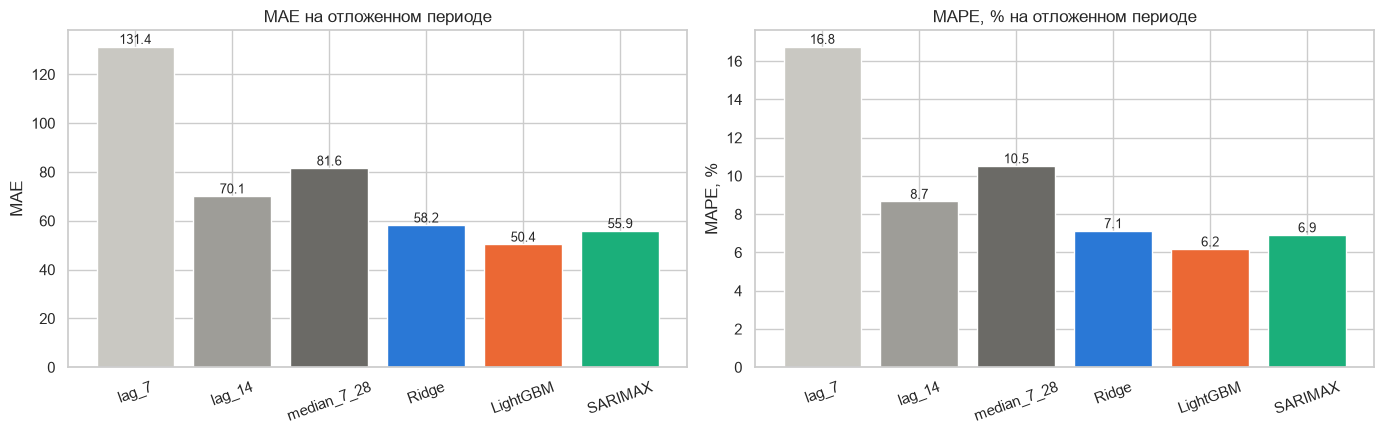

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colors = [palette.get(name, "#1baf7a") for name in HOLDOUT_MODELS]
for ax, metric in zip(axes, ["MAE", "MAPE, %"]):
    bars = ax.bar(HOLDOUT_MODELS, holdout_scores[metric], color=colors)
    ax.bar_label(bars, fmt="%.1f", fontsize=9)
    ax.set(title=f"{metric} на отложенном периоде", ylabel=metric)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

На отложенном периоде лучший результат показывает LightGBM: MAE 50.4 покупателя, MAPE 6.2% и WAPE 6.2%.

Результаты остальных моделей и бейзлайнов:

* SARIMAX - MAE 55.9, MAPE 6.9%;
* Ridge - MAE 58.2, MAPE 7.1%;
* лучший бейзлайн на этом периоде - `lag_14` (MAE 70.1, MAPE 8.7%), затем `median_7_28` (MAE 81.6, MAPE 10.5%) и обязательный `lag_7` (MAE 131.4, MAPE 16.8%).

**Улучшение над бейзлайнами.** LightGBM уменьшает ошибку обязательного бейзлайна `lag_7` на 62% по MAE и на 63% по MAPE. Относительно лучшего на этом периоде бейзлайна `lag_14` ошибка меньше на 28% по MAE и на 29% по MAPE, относительно `median_7_28` - на 38% и 41%.

**Согласованность с фолдами.** Порядок моделей такой же, как в среднем по фолдам: LightGBM, затем SARIMAX, затем Ridge. Ошибка LightGBM на отложенном периоде близка к ошибке в летнем фолде (6.2% против 6.3%), поэтому признаков переобучения на фолдах не видно. Ошибки всех моделей ниже, чем в среднем по фолдам, вероятно, потому, что в отложенном периоде нет государственных праздников и рождественского периода.

**Порядок бейзлайнов изменился.** На отложенном периоде `lag_14` оказался лучше `median_7_28`, хотя на фолдах было наоборот. Летом 2015 года промоакции чередуются регулярно, поэтому значение двухнедельной давности, взятое из той же фазы промоакции, оказывается точнее медианы, которая смешивает недели с промоакцией и без нее. `lag_7`, наоборот, почти всегда берет значение из другой фазы промоакции и ошибается сильнее всех, как и в разделе 2.

### 9.2 Насколько улучшение устойчиво

Одно число на 1470 днях может зависеть от нескольких удачных магазинов или недель. Проверим устойчивость бутстрепом: отложенный период делится на блоки "магазин x неделя" (40 x 6 = 240 блоков), блоки 2000 раз выбираются с возвращением, и на каждой выборке заново считается улучшение модели над бейзлайном. Блоки, а не отдельные дни, сохраняют зависимость соседних дней одного магазина. Интервал - 2.5% и 97.5% перцентили улучшения.

In [32]:
N_BOOT = 2000
blocks = holdout_days["Store"].astype(str) + "_" + ((holdout_days["Date"] - TEST_START).dt.days // 7).astype(str)
# MAE и MAPE каждой модели на одних и тех же бутстреп-выборках блоков (src/customers_prediction/validation.py)
boot = block_bootstrap(y_holdout, holdout_pred, blocks, n_boot=N_BOOT, seed=SEED)
rows = []
for model in ["Ridge", "LightGBM", "SARIMAX"]:
    for base in BASELINES:
        for metric in ["MAE", "MAPE, %"]:
            gain = (1 - boot[model][metric] / boot[base][metric]) * 100
            rows.append({"модель": model, "бейзлайн": base, "метрика": metric,
                         "улучшение, %": (1 - holdout_scores.loc[model, metric] / holdout_scores.loc[base, metric]) * 100,
                         "интервал 2.5%": np.percentile(gain, 2.5), "интервал 97.5%": np.percentile(gain, 97.5),
                         "доля выборок с улучшением, %": (gain > 0).mean() * 100})
bootstrap_table = pd.DataFrame(rows).set_index(["модель", "бейзлайн", "метрика"])

# модели между собой
lgbm_vs = {other: (1 - boot["LightGBM"]["MAPE, %"] / boot[other]["MAPE, %"]) * 100 for other in ["Ridge", "SARIMAX"]}
for other, gain in lgbm_vs.items():
    print(f"LightGBM против {other} (MAPE): улучшение {np.median(gain):.1f}%, "
          f"интервал {np.percentile(gain, 2.5):.1f} - {np.percentile(gain, 97.5):.1f}%, "
          f"доля выборок с улучшением {(gain > 0).mean():.1%}")
bootstrap_table.round(1)

LightGBM против Ridge (MAPE): улучшение 13.4%, интервал 10.3 - 16.4%, доля выборок с улучшением 100.0%
LightGBM против SARIMAX (MAPE): улучшение 10.6%, интервал 6.5 - 14.5%, доля выборок с улучшением 100.0%


улучшение, %  интервал 2.5%  интервал 97.5%  \
модель   бейзлайн    метрика                                                
Ridge    lag_7       MAE              55.7           52.1            59.1   
                     MAPE, %          57.5           54.8            60.1   
         lag_14      MAE              17.0           11.9            21.8   
                     MAPE, %          17.7           13.5            21.7   
         median_7_28 MAE              28.6           23.5            33.8   
                     MAPE, %          32.3           27.6            36.7   
LightGBM lag_7       MAE              61.7           58.7            64.4   
                     MAPE, %          63.2           60.6            65.5   
         lag_14      MAE              28.2           24.2            31.9   
                     MAPE, %          28.7           24.9            32.3   
         median_7_28 MAE              38.2           33.7            42.8   
                     MAPE, %          41.3           36.7            45.6   
SARIMAX  lag_7       MAE              57.5           54.3            60.5   
                     MAPE, %          58.8           56.0            61.4   
         lag_14      MAE              20.3           15.5            24.6   
                     MAPE, %          20.2           16.0            24.0   
         median_7_28 MAE              31.5           26.7            36.0   
                     MAPE, %          34.3           29.7            38.6   

                              доля выборок с улучшением, %  
модель   бейзлайн    метрика                                
Ridge    lag_7       MAE                             100.0  
                     MAPE, %                         100.0  
         lag_14      MAE                             100.0  
                     MAPE, %                         100.0  
         median_7_28 MAE                             100.0  
                     MAPE, %                         100.0  
LightGBM lag_7       MAE                             100.0  
                     MAPE, %                         100.0  
         lag_14      MAE                             100.0  
                     MAPE, %                         100.0  
         median_7_28 MAE                             100.0  
                     MAPE, %                         100.0  
SARIMAX  lag_7       MAE                             100.0  
                     MAPE, %                         100.0  
         lag_14      MAE                             100.0  
                     MAPE, %                         100.0  
         median_7_28 MAE                             100.0  
                     MAPE, %                         100.0

Улучшение устойчиво. Во всех 2000 бутстреп-выборках каждая модель (LightGBM, SARIMAX и Ridge) лучше каждого бейзлайна и по MAE, и по MAPE.

Для LightGBM интервалы улучшения MAPE составляют:

* 60.6-65.5% относительно `lag_7`;
* 24.9-32.3% относительно `lag_14`;
* 36.7-45.6% относительно `median_7_28`.

Даже нижняя граница интервала относительно самого сильного на этом периоде бейзлайна `lag_14` - около 25%, то есть улучшение не объясняется несколькими удачными магазинами или неделями.

LightGBM также лучше альтернативных моделей во всех бутстреп-выборках: MAPE меньше, чем у Ridge, на 10.3-16.4%, и меньше, чем у SARIMAX, на 6.5-14.5%.

### 9.3 Качество по группам магазинов и дням

Метрики в целом могут скрывать группы, где модель работает хуже. Смотрим MAPE по сегментам, по проблемным группам магазинов из ноутбука `01_data_research`, по дням недели и по неделям отложенного периода, а также долю магазинов, где модель лучше бейзлайна.

In [33]:
ape_holdout = pd.DataFrame({name: (pred - y_holdout).abs() / y_holdout * 100 for name, pred in holdout_pred.items()})
store_flags = selected.loc[holdout_days["Store"].to_numpy()].set_index(holdout_days.index)
GROUPS = {
    "все магазины": pd.Series(True, index=holdout_days.index),
    "сегмент mid": holdout_days["segment"] == "mid",
    "сегмент high_check": holdout_days["segment"] == "high_check",
    "сегмент high_traffic": holdout_days["segment"] == "high_traffic",
    "пробел выгрузки 2014": store_flags["has_export_gap"],
    "длинные закрытия": store_flags["has_long_closure"],
    "открытие конкурента в трейне": store_flags["competitor_opened_in_train"],
    "появились в данных позже": store_flags["has_left_censored"],
    "аномальные дни в трейне": store_flags["has_anomaly"],
}
group_table = pd.DataFrame({group: {"магазинов": holdout_days.loc[mask, "Store"].nunique(), **ape_holdout[mask].mean()}
                            for group, mask in GROUPS.items()}).T
display(group_table.round(1))

store_mape = ape_holdout.groupby(holdout_days["Store"]).mean()
print(f"Доля магазинов, где LightGBM лучше lag_7: {(store_mape['LightGBM'] < store_mape['lag_7']).mean():.0%}, "
      f"лучше median_7_28: {(store_mape['LightGBM'] < store_mape['median_7_28']).mean():.0%}, "
      f"лучше SARIMAX: {(store_mape['LightGBM'] < store_mape['SARIMAX']).mean():.0%}")

day_names = {1: "Пн", 2: "Вт", 3: "Ср", 4: "Чт", 5: "Пт", 6: "Сб", 7: "Вс"}
by_day = ape_holdout.groupby(holdout_days["DayOfWeek"].map(day_names), sort=False).mean()
by_week = ape_holdout.groupby(((holdout_days["Date"] - TEST_START).dt.days // 7 + 1).rename("неделя")).mean()
display(by_day.loc[list(day_names.values())].round(1))
by_week.round(1)

,магазинов,lag_7,lag_14,median_7_28,Ridge,LightGBM,SARIMAX
все магазины,40.0,16.8,8.7,10.5,7.1,6.2,6.9
сегмент mid,24.0,17.3,8.6,10.7,7.2,6.3,6.8
сегмент high_check,11.0,18.1,8.7,11.4,7.2,6.0,7.3
сегмент high_traffic,5.0,12.3,8.8,8.2,6.8,6.0,6.7
пробел выгрузки 2014,9.0,16.1,7.6,9.6,7.1,6.1,6.4
длинные закрытия,9.0,15.0,9.1,9.9,7.6,6.6,7.5
открытие конкурента в трейне,8.0,14.1,8.2,9.3,6.9,5.8,6.4
появились в данных позже,2.0,12.1,8.9,8.6,6.5,6.2,6.9
аномальные дни в трейне,5.0,16.6,9.0,10.5,7.6,6.5,7.5


Доля магазинов, где LightGBM лучше lag_7: 100%, лучше median_7_28: 100%, лучше SARIMAX: 82%


,lag_7,lag_14,median_7_28,Ridge,LightGBM,SARIMAX
DayOfWeek,,,,,,
Пн,24.2,8.4,14.1,7.6,6.0,7.1
Вт,26.0,9.5,14.5,8.0,6.2,7.0
Ср,17.1,8.4,10.0,6.4,5.6,6.3
Чт,12.7,7.4,8.1,6.3,6.3,6.4
Пт,13.4,8.3,9.1,7.1,5.6,7.1
Сб,8.4,10.3,8.0,7.6,7.5,7.6
Вс,6.8,6.3,5.2,5.1,5.3,6.2


,lag_7,lag_14,median_7_28,Ridge,LightGBM,SARIMAX
неделя,,,,,,
1,20.8,8.6,16.6,7.5,5.2,6.7
2,17.3,7.5,9.6,7.6,6.7,8.1
3,18.6,8.8,9.4,7.7,7.1,6.6
4,11.7,8.9,7.0,5.9,5.6,6.6
5,16.7,8.4,10.6,5.8,5.8,5.9
6,15.5,9.8,10.0,8.3,6.6,7.6


**Группы магазинов.** LightGBM лучше всех остальных моделей и бейзлайнов во всех группах магазинов:

* по сегментам качество ровное: MAPE 6.0-6.3%, хотя на фолдах сегмент `high_traffic` был сложнее остальных;
* магазины с длинными закрытиями и с аномальными днями в трейне прогнозируются немного хуже среднего: MAPE 6.6% и 6.5% против 6.2% по всем магазинам;
* магазины с пробелом в выгрузке 2014 года прогнозируются не хуже среднего (6.1%). Вероятно, к лету 2015 года у них уже накопилось полгода свежей истории.

LightGBM лучше `lag_7` и `median_7_28` у всех 40 магазинов и лучше SARIMAX у 82% магазинов.

**Дни недели.** LightGBM показывает лучший или равный лучшему результат во все дни, кроме воскресенья: в воскресенье его MAPE 5.3% против 5.1% у Ridge, но по воскресеньям открыты только 5 магазинов. Сложнее всего для всех моделей суббота: у LightGBM MAPE 7.5%, у остальных моделей не лучше. Возможная причина - по субботам промоакций нет, и спрос в этот день хуже описывается признаками.

У `lag_7` ошибка в дни, когда может проходить промоакция (с понедельника по пятницу), составляет 13-26%, а в субботу, когда промоакций не бывает, - 8%. Это та же проблема смены фазы промоакции, что и в разделе 2.

**Недели отложенного периода.** LightGBM показывает лучший или равный лучшему результат в 5 из 6 недель. В третьей неделе лучше SARIMAX: 6.6% против 7.1%.

## 10. Анализ ошибок

Разбираем ошибки основной модели LightGBM на отложенном периоде: у каких магазинов и в какие дни она ошибается сильнее всего и почему.

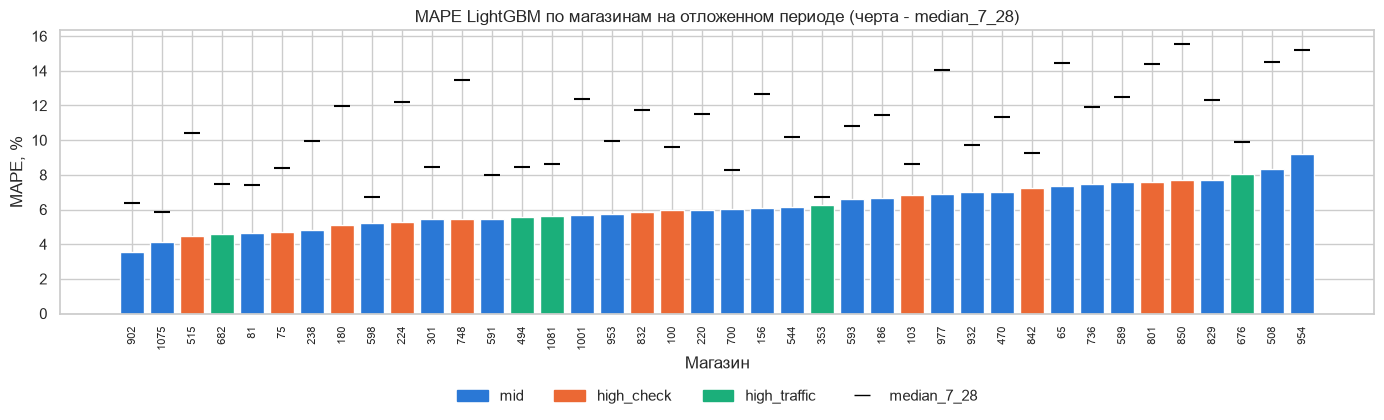

,segment,"MAPE LightGBM, %","MAPE median_7_28, %","MAPE SARIMAX, %","смещение LightGBM, %",особенности
Store,,,,,,
954,mid,9.2,15.2,9.5,-0.5,competitor_opened_in_train
508,mid,8.3,14.5,8.5,0.1,-
676,high_traffic,8.1,9.9,8.6,1.4,has_long_closure
829,mid,7.7,12.3,9.1,-2.5,-
850,high_check,7.7,15.6,9.8,-2.0,"has_long_closure, has_anomaly"
801,high_check,7.6,14.4,10.0,-3.5,competitor_opened_in_train


In [34]:
SEGMENT_COLORS = {"mid": "#2a78d6", "high_check": "#eb6834", "high_traffic": "#1baf7a"}   # как в ноутбуке 02_eda
order = store_mape["LightGBM"].sort_values().index
store_segment = selected.loc[order, "segment"]
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(range(len(order)), store_mape.loc[order, "LightGBM"], color=[SEGMENT_COLORS[s] for s in store_segment])
ax.scatter(range(len(order)), store_mape.loc[order, "median_7_28"], color="black", marker="_", s=120, zorder=3)
ax.set_xticks(range(len(order)), order, rotation=90, fontsize=8)
ax.set(title="MAPE LightGBM по магазинам на отложенном периоде (черта - median_7_28)", xlabel="Магазин", ylabel="MAPE, %")
ax.legend(handles=[Patch(color=c, label=s) for s, c in SEGMENT_COLORS.items()]
          + [plt.Line2D([], [], color="black", marker="_", linestyle="", markersize=12, label="median_7_28")],
          loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

bias = ((holdout_pred["LightGBM"] - y_holdout) / y_holdout * 100).groupby(holdout_days["Store"]).mean()
flag_columns = ["has_export_gap", "has_long_closure", "competitor_opened_in_train", "has_left_censored", "has_anomaly"]
worst = order[::-1][:6]
(pd.DataFrame({"segment": selected.loc[worst, "segment"],
               "MAPE LightGBM, %": store_mape.loc[worst, "LightGBM"],
               "MAPE median_7_28, %": store_mape.loc[worst, "median_7_28"],
               "MAPE SARIMAX, %": store_mape.loc[worst, "SARIMAX"],
               "смещение LightGBM, %": bias.loc[worst],
               "особенности": selected.loc[worst, flag_columns].apply(
                   lambda r: ", ".join(c for c in flag_columns if r[c]) or "-", axis=1)})
 .round(1))

MAPE LightGBM по магазинам меняется от 3.5% (магазин 902) до 9% (магазин 954). При этом у каждого магазина ошибка LightGBM ниже, чем у бейзлайна `median_7_28`.

У магазинов с наибольшей ошибкой смещение небольшое: от -3.5% до +1.4%. Это значит, что модель в целом правильно оценивает уровень магазина, а ошибается в основном в колебаниях от дня к дню.

Среди 6 магазинов с наибольшей ошибкой 4 относятся к проблемным: у двух в период трейна открылся конкурент, еще у двух были длинные закрытия. Но их ошибка ненамного выше типичной: MAPE 7.6-9.2% при медиане по магазинам около 6%.

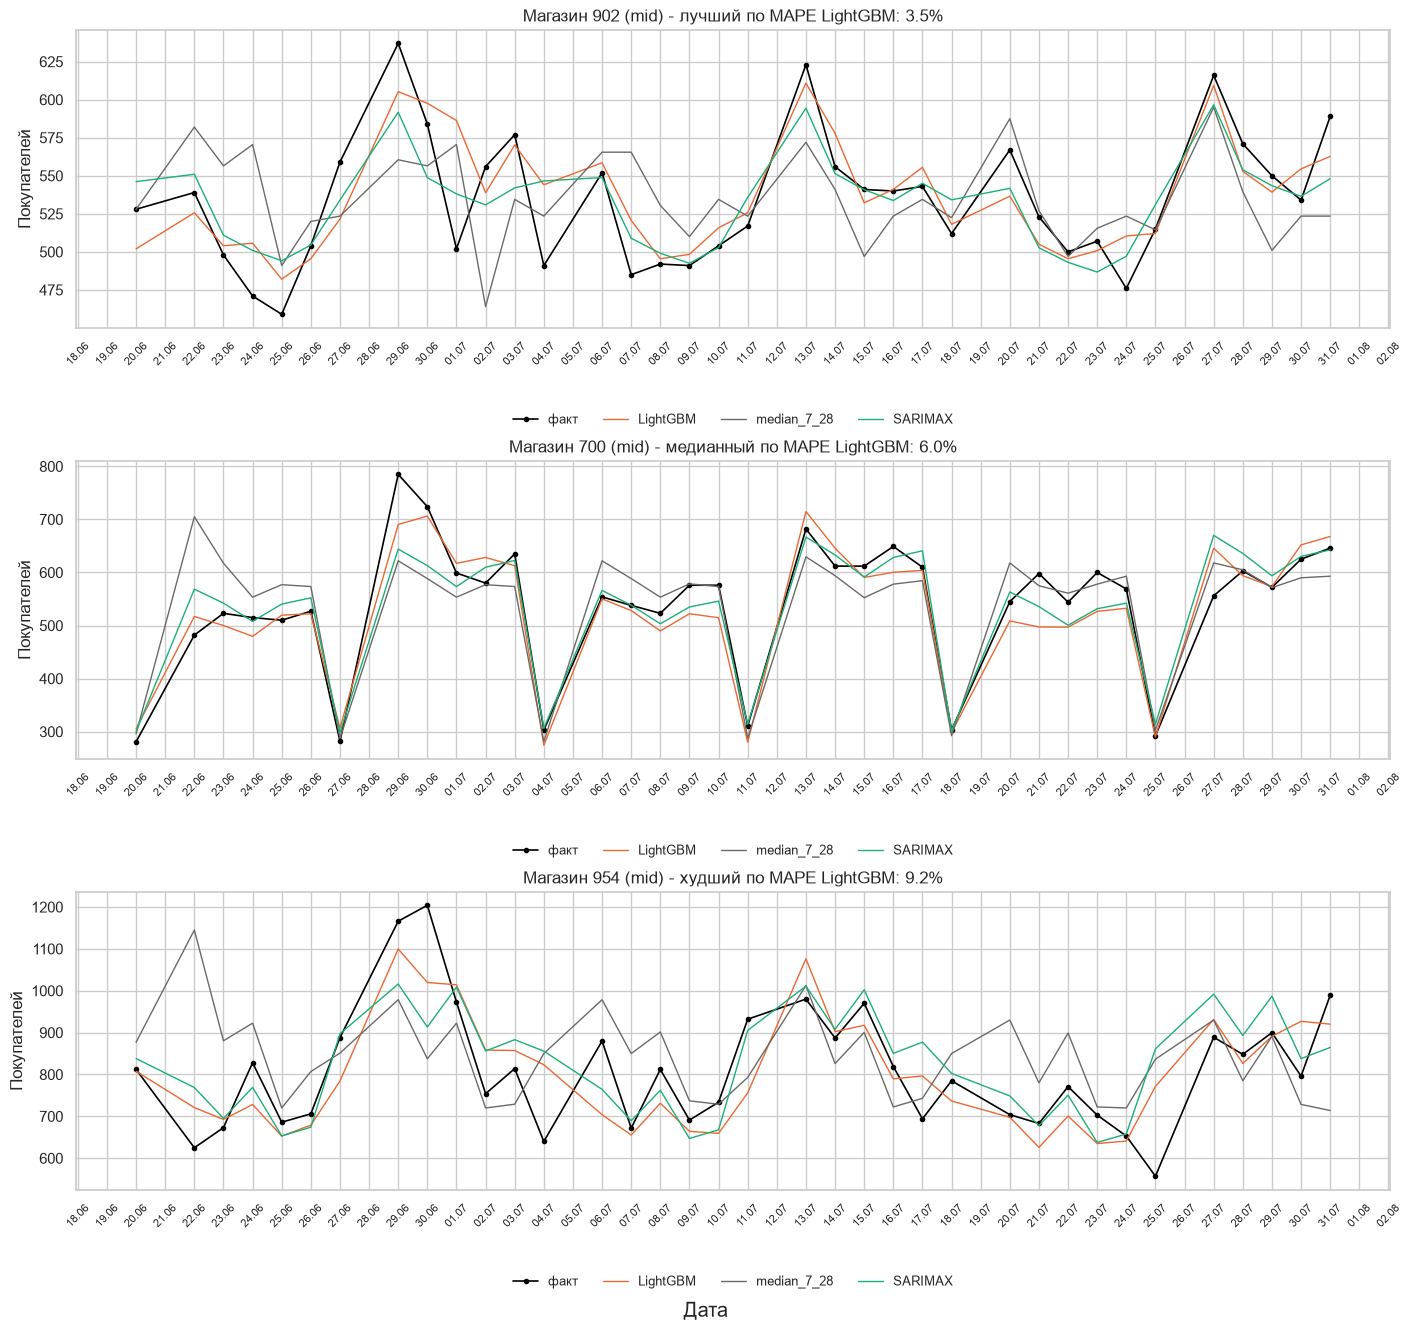

In [35]:
examples = {"лучший": order[0], "медианный": order[len(order) // 2], "худший": order[-1]}
fig, axes = plt.subplots(len(examples), 1, figsize=(14, 4.4 * len(examples)), sharex=True, layout="constrained")
for ax, (label, store) in zip(axes, examples.items()):
    rows = holdout_days.index[holdout_days["Store"] == store]
    dates = holdout_days.loc[rows, "Date"]
    ax.plot(dates, y_holdout.loc[rows], color="black", marker="o", markersize=3, linewidth=1.2, label="факт")
    for name, color in [("LightGBM", "#eb6834"), ("median_7_28", "#6b6a66"), ("SARIMAX", "#1baf7a")]:
        ax.plot(dates, holdout_pred[name].loc[rows], color=color, linewidth=1, label=name)
    ax.set(title=f"Магазин {store} ({selected.loc[store, 'segment']}) - {label} по MAPE LightGBM: "
                 f"{store_mape.loc[store, 'LightGBM']:.1f}%", ylabel="Покупателей")
    ax.xaxis.set_major_locator(mdates.DayLocator())               # подпись у каждого дня
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
    ax.tick_params(axis="x", labelbottom=True, rotation=45, labelsize=8)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=4, fontsize=9, frameon=False)
fig.supxlabel("Дата")
plt.show()

LightGBM хорошо воспроизводит недельный профиль и чередование промоакций: в недели с промоакцией прогноз поднимается, а в недели без нее опускается. `median_7_28` эту разницу сглаживает, потому что смешивает недели с промоакцией и без нее.

Основные ошибки модели связаны с пиками и провалами отдельных дней:

* самый заметный пик - конец июня. 29.06.2015 фактическое число покупателей у всех трех магазинов выше прогноза. Например, у магазина 954 в конце июня было около 1170-1200 покупателей в день, а прогноз составлял 1020-1100. Вероятно, это эффект конца месяца, который признак дня месяца (раздел 7.1) учитывает лишь частично;
* разовые провалы, например у магазина 954 22.06 и 25.07, не предсказывает ни одна модель: по календарю они ничем не выделяются.

Проверим, есть ли дни, когда модель ошибается одновременно у многих магазинов: такие ошибки указывают на общий внешний фактор, которого нет в признаках (например, как массовые снижения из раздела 7.4 ноутбука `02_eda`, когда покупателей стало резко меньше обычного сразу у нескольких магазинов, хотя по календарю - обычный день).

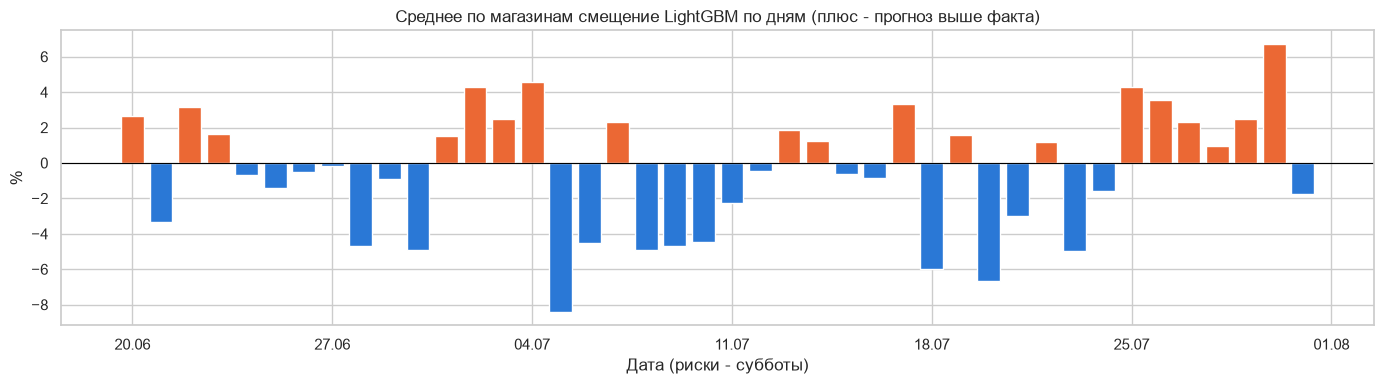

,"смещение, %",магазинов с ошибкой больше 20%,день
Date,,,
2015-07-05,-8.4,0,Sunday
2015-07-30,6.7,1,Thursday
2015-07-20,-6.7,0,Monday
2015-07-18,-6.0,1,Saturday
2015-07-23,-5.0,0,Thursday
2015-07-08,-4.9,1,Wednesday


In [36]:
signed = (holdout_pred["LightGBM"] - y_holdout) / y_holdout * 100
daily = pd.DataFrame({"смещение, %": signed.groupby(holdout_days["Date"]).mean(),
                      "магазинов с ошибкой больше 20%": (signed.abs() > 20).groupby(holdout_days["Date"]).sum()})

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily.index, daily["смещение, %"], color=np.where(daily["смещение, %"] > 0, "#eb6834", "#2a78d6"))
ax.axhline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SA))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.set(title="Среднее по магазинам смещение LightGBM по дням (плюс - прогноз выше факта)", xlabel="Дата (риски - субботы)",
       ylabel="%")
plt.tight_layout()
plt.show()

daily.assign(день=daily.index.day_name()).sort_values("смещение, %", key=abs, ascending=False).head(6).round(1)

Среднее по магазинам смещение LightGBM по дням не превышает 9%. Даже в дни с наибольшим смещением ошибка больше 20% встречается не более чем у одного магазина. Значит, массовых провалов спроса, как в разделе 7.4 ноутбука `02_eda`, в отложенном периоде нет.

Самое большое смещение (-8.4%) приходится на воскресенье 5 июля. Но по воскресеньям открыты только 5 магазинов `high_traffic`, поэтому среднее за этот день рассчитано по небольшому числу магазинов и сильно зависит от каждого из них.

Смещение меняется блоками по несколько дней: в начале июля модель в основном занижает прогноз, а в последнюю неделю июля - завышает (до +6.7%). Это похоже на общий для всех магазинов сдвиг спроса, который модель замечает с запозданием, так как уровень магазина рассчитывается по данным не позже `t - 7`. Проверить причину этого сдвига по данным отложенного периода нельзя.

## Итоговые выводы ноутбука

**Постановка задачи.** Прогноз числа покупателей на 7 дней вперед строится одной моделью: все признаки для дня `t` берутся из истории не позже `t - 7` и из заранее известного плана на день `t` (промоакции, праздники, расписание работы). Отсутствие утечки из будущего проверено напрямую в разделе 3.2. Все решения приняты по трем фолдам внутри трейна с расширяющимся окном (зима, весна, лето). Отложенный период 20.06-31.07.2015 использован один раз - для финального сравнения моделей.

**Бейзлайны.** Обязательный наивный бейзлайн "тот же день неделю назад" (`lag_7`) систематически ошибается из-за чередования промоакций: неделю назад фаза промоакции обычно была другой. Бейзлайны, которые это учитывают (`lag_14` и `median_7_28`), заметно точнее.

**Модели.** Целевая переменная - отклонение числа покупателей от недавнего уровня магазина в логарифмической шкале. Признаки описывают лаги того же дня недели, промоакции, календарь праздников и событий (Пасха, Рождество, карнавал), закрытия магазинов и характеристики магазина. Наибольший вклад в прогноз дают праздники и события, лаги, промоакция в день прогноза и номер магазина.

LightGBM на тех же признаках точнее Ridge, особенно в рождественский период, где эффект дня зависит от сочетания нескольких признаков. Не подтвердились ограничение выбросов при обучении, признак Promo2 и отдельные модели для сегментов `mid` и `high_traffic`. Отдельная модель принята только для сегмента `high_check`, причем с небольшим запасом.

**Результат на отложенном периоде.** LightGBM показывает MAE 50.4 покупателя и MAPE 6.2%. У обязательного бейзлайна `lag_7` эти значения составляют 131.4 и 16.8%, то есть ошибка снижена на 62% и 63%. У лучшего на этом периоде бейзлайна `lag_14` - 70.1 и 8.7%, ошибка снижена на 28% и 29%. Улучшение устойчиво: по бутстрепу блоков "магазин x неделя" LightGBM лучше каждого бейзлайна во всех выборках. Кроме того, LightGBM лучше бейзлайнов у всех 40 магазинов и во всех группах, включая проблемные магазины.

**Альтернативный подход к сезонности.** SARIMAX (регрессия с ошибками ARIMA(1, 1, 1), отдельная модель для каждого магазина) - сильная альтернатива. На отложенном периоде его MAPE 6.9%, это лучше Ridge и всех бейзлайнов, а в зимнем фолде SARIMAX даже точнее LightGBM за счет более свежих данных. Но в среднем он уступает LightGBM, требует отдельной модели для каждого магазина и оценивается намного дольше: около 20 минут на две спецификации и три фолда против нескольких секунд у LightGBM.

**Ограничения:**

* в отложенном периоде нет государственных праздников, поэтому качество в праздники известно только по фолдам. Зимой MAPE LightGBM составляет 12.9%, то есть примерно вдвое больше, чем летом;
* выборка включает 40 магазинов, а группы проблемных магазинов в ней небольшие (2-9 магазинов);
* эффект конца месяца учитывается лишь частично, а разовые провалы спроса нельзя предсказать по календарю.

**Возможные направления развития.**

**1. Использовать более свежие данные.** Сейчас для всех 7 дней горизонта признаки берутся из данных не позже `t - 7`. Для последнего дня горизонта это естественный предел: более свежих данных на дату прогноза нет. Но для первых дней горизонта модель не видит до 6 уже известных дней. Такое правило выбрано сознательно: одна модель подходит для всех дней горизонта, утечка исключена по построению, а прогноз устроен просто. Цена этого решения - потеря самых свежих данных.

Что это может дать, показывает раздел 8: SARIMAX, который использует историю до дня перед датой прогноза, в зимнем фолде точнее LightGBM (12.1% против 12.9%). В рождественский период спрос быстро меняется, и данные недельной давности устаревают. В разделе 10 видно похожее: смещение прогноза меняется блоками по несколько дней, то есть модель замечает общий сдвиг спроса с запаздыванием.

Вариант реализации - строить обучающие данные как пары "дата прогноза x горизонт" (горизонт от 1 до 7 дней) и передавать горизонт модели как признак. Тогда лаги и уровень магазина считаются от даты прогноза, и для ближних дней горизонта модель получает самые свежие данные. Обучающих строк станет в 7 раз больше, а построение признаков потребует дополнительной проверки на утечку.

**2. Ridge с взаимодействиями признаков.** Ridge складывает эффекты признаков независимо: у промоакции один эффект для всех сегментов, у дня недели - один профиль для всех магазинов. Но в ноутбуке `02_eda` видно, что эффекты зависят друг от друга: промоакция по-разному влияет на разные сегменты (раздел 8.2), а недельный профиль у каждого сегмента и магазина свой (раздел 3.3). LightGBM находит такие сочетания сам, и именно поэтому он особенно выигрывает у Ridge зимой.

Линейной модели такие сочетания можно передать явно - в виде признаков-произведений, например `Promo x segment`, `DayOfWeek x segment` и `DayOfWeek x Promo`. Такой эксперимент покажет, какую часть отставания Ridge можно закрыть ручными признаками. Если отставание окажется небольшим, можно использовать более простую и интерпретируемую модель: каждый вес Ridge читается как поправка к числу покупателей в процентах.

**3. Внешние данные.** Часть ошибок нельзя устранить признаками из имеющихся данных:
* массовые снижения спроса: в обычный день покупателей резко меньше сразу у многих магазинов, например 12 марта 2013 года - у 10 магазинов (раздел 7.4 ноутбука `02_eda`). Вероятная причина - погода, например снегопад или гололед;
* разовые провалы отдельных магазинов, которые по календарю ничем не выделяются (например, у магазина 954 22.06 и 25.07, раздел 10);
* местные события, например повторяющийся выброс у магазина 953 в субботу перед первым адвентом (раздел 7.4 ноутбука `02_eda`): ярмарки, фестивали, спортивные матчи.

Данные о погоде (температура, осадки, снег) и календарь местных событий по городу магазина могли бы объяснить часть таких дней. Для ресторанов это особенно важно: посещаемость сильно зависит от погоды, а работа летних веранд - напрямую. При этом для прогноза на неделю вперед доступен только прогноз погоды, а не фактическая погода, поэтому модель нужно обучать на исторических прогнозах погоды. Иначе при обучении модель будет казаться точнее, чем окажется в реальной работе.